#  Proyecto Integrador UD03 — Fórmula 1
## Análisis Exploratorio de Datos con NumPy y Pandas

---

| | |
|---|---|
| **Autor** | Fran Cámara Martínez |
| **Asignatura** | Análisis y Explotación de Datos |
| **Dataset** | Fórmula 1 World Championship (1950–2024) |
| **Herramientas** | Python · NumPy · Pandas · Matplotlib · Seaborn |

---

##  Descripción del Proyecto

Este notebook realiza un análisis exhaustivo del dataset histórico de la Fórmula 1, que cubre resultados, pilotos, constructores, circuitos, clasificaciones y tiempos desde los orígenes del campeonato hasta la temporada 2024.

---

#  FASE 1: Preparación y Carga de Datos

En esta primera fase se importan las bibliotecas necesarias, se cargan todos los archivos CSV del dataset y se realiza una limpieza de los datos para asegurar su calidad antes del análisis.

Objetivos de esta fase:
- Importar las dependencias del proyecto
- Cargar los 14 datasets CSV
- Detectar y tratar valores nulos, duplicados y tipos erróneos
- Preparar el DataFrame principal integrado (`df`) para las fases siguientes

## 1.1 Importación de Librerías

Se importan las librerías estándar para análisis de datos en Python:
- **pandas**: manipulación de DataFrames
- **numpy**: cálculos numéricos y estadísticos
- **matplotlib / seaborn**: visualización de datos
- **os / warnings**: utilidades del sistema

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Configuración global
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

print(" Librerías importadas correctamente")
print(f"   pandas  v{pd.__version__}")
print(f"   numpy   v{np.__version__}")

 Librerías importadas correctamente
   pandas  v2.3.3
   numpy   v2.3.5


## 1.2 Carga de los Datasets

Se establece la ruta base relativa para que el notebook funcione en cualquier equipo independientemente del sistema operativo. Se cargan los 7 archivos principales necesarios para el análisis.



In [3]:
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.getcwd()
    for _ in range(3):
        if os.path.exists(os.path.join(NOTEBOOK_DIR, "datos")):
            break
        parent = os.path.dirname(NOTEBOOK_DIR)
        if parent == NOTEBOOK_DIR:
            break
        NOTEBOOK_DIR = parent

# Fijar el directorio de trabajo
os.chdir(NOTEBOOK_DIR)
BASE_PATH = "datos"

# Carga de todos los datasets
drivers               = pd.read_csv(os.path.join(BASE_PATH, "drivers.csv"))
constructors          = pd.read_csv(os.path.join(BASE_PATH, "constructors.csv"))
circuits              = pd.read_csv(os.path.join(BASE_PATH, "circuits.csv"))
results               = pd.read_csv(os.path.join(BASE_PATH, "results.csv"))
status                = pd.read_csv(os.path.join(BASE_PATH, "status.csv"))
seasons               = pd.read_csv(os.path.join(BASE_PATH, "seasons.csv"))
races                 = pd.read_csv(os.path.join(BASE_PATH, "races.csv"))
driver_standings      = pd.read_csv(os.path.join(BASE_PATH, "driver_standings.csv"))
constructor_standings = pd.read_csv(os.path.join(BASE_PATH, "constructor_standings.csv"))
qualifying            = pd.read_csv(os.path.join(BASE_PATH, "qualifying.csv"))
lap_times             = pd.read_csv(os.path.join(BASE_PATH, "lap_times.csv"))
pit_stops             = pd.read_csv(os.path.join(BASE_PATH, "pit_stops.csv"))
sprint_results        = pd.read_csv(os.path.join(BASE_PATH, "sprint_results.csv"))
constructor_results   = pd.read_csv(os.path.join(BASE_PATH, "constructor_results.csv"))

print("\n Todos los datasets cargados correctamente")
print(f"\n{'Dataset':<30} {'Filas':>8} {'Columnas':>10}")
print("-" * 50)
datasets_info = {
    'results': results, 'drivers': drivers, 'constructors': constructors,
    'races': races, 'circuits': circuits, 'status': status,
    'driver_standings': driver_standings, 'qualifying': qualifying,
    'lap_times': lap_times, 'pit_stops': pit_stops
}
for name, df_tmp in datasets_info.items():
    print(f"  {name:<28} {len(df_tmp):>8,} {len(df_tmp.columns):>10}")


 Todos los datasets cargados correctamente

Dataset                           Filas   Columnas
--------------------------------------------------
  results                        26,759         18
  drivers                           861          9
  constructors                      212          5
  races                           1,125         18
  circuits                           77          9
  status                            139          2
  driver_standings               34,863          7
  qualifying                     10,494          9
  lap_times                     589,081          6
  pit_stops                      11,371          7


## 1.3 Inspección Inicial de los Datos

Antes de limpiar, se examina la estructura y calidad de los datos:
- **Tipos de datos** de cada columna
- **Valores nulos** o marcadores especiales (`\\N`)
- **Duplicados** potenciales
- **Rango de valores** para detectar anomalías


In [4]:
# Inspección del dataset principal
print("="*60)
print("INSPECCIÓN INICIAL DE RESULTS")
print("="*60)
print(f"Dimensiones: {results.shape[0]:,} filas × {results.shape[1]} columnas")
print()
results.info()
print()
print("Primeras filas:")
results.head()

INSPECCIÓN INICIAL DE RESULTS
Dimensiones: 26,759 filas × 18 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.00,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.00,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.00,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.00,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.00,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [5]:
# Detectar valores especiales '\N' ya que en el anteriror trabajo salian pues ver los valores y limpiarlos
print("Valores '\\N' detectados por columna:")
for col in results.columns:
    count_backslash_n = (results[col].astype(str) == '\\N').sum()
    if count_backslash_n > 0:
        print(f"  {col:25s}: {count_backslash_n:>6,} valores \\N")

print()
print("Valores nulos (NaN) por columna:")
nulls = results.isnull().sum()
print(nulls[nulls > 0])

Valores '\N' detectados por columna:
  number                   :      6 valores \N
  position                 : 10,953 valores \N
  time                     : 19,079 valores \N
  milliseconds             : 19,079 valores \N
  fastestLap               : 18,507 valores \N
  rank                     : 18,249 valores \N
  fastestLapTime           : 18,507 valores \N
  fastestLapSpeed          : 18,507 valores \N

Valores nulos (NaN) por columna:
Series([], dtype: int64)


## 1.4 Limpieza de Datos

La limpieza es un paso crítico. Se identificaron los siguientes problemas en el dataset:

1. **Marcadores `\N`**: El CSV usa `\N` para valores desconocidos (herencia de MySQL). Se convierten a `NaN`.
2. **Columna `position`**: Es `object` porque contiene tanto números como `\N` (DNF sin posición asignada).
3. **Columna `milliseconds`**: Debería ser numérica pero contiene `\N`.
4. **Columna `fastestLap` y `rank`**: Mismo problema, se convierten a numérico.
5. **Columna `fastestLapSpeed`**: Almacenada como cadena de texto; se convierte a `float`.
6. **Duplicados**: Se verifica y elimina cualquier resultado duplicado por (raceId, driverId).
7. **`number`**: El número de dorsal puede ser `\N` si el piloto es sustituto.

In [6]:
#LIMPIEZA COMPLETA

results_clean = results.copy()

# 1. Reemplazar \N por NaN en todo el DataFrame
results_clean.replace('\\N', np.nan, inplace=True)

# 2. Convertir columnas numéricas que llegaron como object
cols_to_numeric = ['position', 'milliseconds', 'fastestLap', 'rank', 
                   'fastestLapSpeed', 'number']
for col in cols_to_numeric:
    results_clean[col] = pd.to_numeric(results_clean[col], errors='coerce')

# 3. Rellenar puntos nulos con 0
results_clean['points'] = results_clean['points'].fillna(0)

# 4. Eliminar duplicados
n_before = len(results_clean)
results_clean.drop_duplicates(subset=['raceId', 'driverId'], keep='first', inplace=True)
n_after = len(results_clean)
print(f"Duplicados eliminados: {n_before - n_after}")

# 5. Verificar resultado final
print()
print("TIPOS DE DATOS TRAS LA LIMPIEZA:")
print(results_clean.dtypes)
print()
print("NULOS RESTANTES (semánticamente válidos):")
print(results_clean.isnull().sum()[results_clean.isnull().sum() > 0])
print()
print(f" Dataset limpio: {len(results_clean):,} registros")

Duplicados eliminados: 91

TIPOS DE DATOS TRAS LA LIMPIEZA:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number             float64
grid                 int64
position           float64
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds       float64
fastestLap         float64
rank               float64
fastestLapTime      object
fastestLapSpeed    float64
statusId             int64
dtype: object

NULOS RESTANTES (semánticamente válidos):
number                 6
position           10917
time               19005
milliseconds       19005
fastestLap         18416
rank               18158
fastestLapTime     18416
fastestLapSpeed    18416
dtype: int64

 Dataset limpio: 26,668 registros


## 1.5 Limpieza de Tablas Auxiliares

Se limpian también las tablas de pilotos, constructores y carreras que se usarán en los merge posteriores.

In [7]:
# ── LIMPIEZA DE DATASETS AUXILIARES ───────────────────────────────────────

# drivers: limpiar number y code con \N
drivers_clean = drivers.copy()
drivers_clean.replace('\\N', np.nan, inplace=True)
drivers_clean['number'] = pd.to_numeric(drivers_clean['number'], errors='coerce')

#Limpiar columnas de horario con \N
races_clean = races[['raceId', 'year', 'round', 'circuitId', 'name']].copy()
races_clean.replace('\\N', np.nan, inplace=True)
races_clean['year'] = pd.to_numeric(races_clean['year'], errors='coerce')

# Limpiar tiempos
qualifying_clean = qualifying.copy()
qualifying_clean.replace('\\N', np.nan, inplace=True)

lap_times_clean = lap_times.copy()
lap_times_clean['milliseconds'] = pd.to_numeric(lap_times_clean['milliseconds'], errors='coerce')

print(" Tablas auxiliares limpias")
print(f"  drivers_clean:    {len(drivers_clean):>6,} filas")
print(f"  races_clean:      {len(races_clean):>6,} filas")
print(f"  qualifying_clean: {len(qualifying_clean):>6,} filas")
print(f"  lap_times_clean:  {len(lap_times_clean):>6,} filas")

 Tablas auxiliares limpias
  drivers_clean:       861 filas
  races_clean:       1,125 filas
  qualifying_clean: 10,494 filas
  lap_times_clean:  589,081 filas


## 1.6 Construcción del DataFrame Principal Integrado

Se construye el DataFrame unificado que combina resultados, pilotos, constructores, status y año de carrera. Este será el dataset base para todas las fases de análisis.

In [8]:
# Seleccionar columnas necesarias de cada tabla
drivers_sel      = drivers_clean[['driverId', 'code', 'forename', 'surname', 'nationality', 'dob']]
constructors_sel = constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'})
status_sel       = status[['statusId', 'status']]
races_sel        = races_clean[['raceId', 'year', 'round', 'circuitId']]

df = (results_clean
      .merge(drivers_sel,      on='driverId',      how='left')
      .merge(constructors_sel, on='constructorId',  how='left')
      .merge(status_sel,       on='statusId',       how='left')
      .merge(races_sel,        on='raceId',         how='left'))

df['pos_delta'] = df['grid'] - df['positionOrder']

df['dnf'] = (df['statusId'] != 1).astype(int)

print(f" DataFrame integrado creado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print()
print("Columnas disponibles:")
print(list(df.columns))
print()
df.head()

 DataFrame integrado creado: 26,668 filas × 30 columnas

Columnas disponibles:
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'code', 'forename', 'surname', 'nationality', 'dob', 'constructor_name', 'status', 'year', 'round', 'circuitId', 'pos_delta', 'dnf']



,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,code,forename,surname,nationality,dob,constructor_name,status,year,round,circuitId,pos_delta,dnf
0,1,18,1,1,22.00,1,1.00,1,1,10.00,58,1:34:50.616,5690616.00,39.00,2.00,1:27.452,218.30,1,HAM,Lewis,Hamilton,British,1985-01-07,McLaren,Finished,2008,1,1,0,0
1,2,18,2,2,3.00,5,2.00,2,2,8.00,58,+5.478,5696094.00,41.00,3.00,1:27.739,217.59,1,HEI,Nick,Heidfeld,German,1977-05-10,BMW Sauber,Finished,2008,1,1,3,0
2,3,18,3,3,7.00,7,3.00,3,3,6.00,58,+8.163,5698779.00,41.00,5.00,1:28.090,216.72,1,ROS,Nico,Rosberg,German,1985-06-27,Williams,Finished,2008,1,1,4,0
3,4,18,4,4,5.00,11,4.00,4,4,5.00,58,+17.181,5707797.00,58.00,7.00,1:28.603,215.46,1,ALO,Fernando,Alonso,Spanish,1981-07-29,Renault,Finished,2008,1,1,7,0
4,5,18,5,1,23.00,3,5.00,5,5,4.00,58,+18.014,5708630.00,43.00,1.00,1:27.418,218.38,1,KOV,Heikki,Kovalainen,Finnish,1981-10-19,McLaren,Finished,2008,1,1,-2,0


---

#  FASE 2: Análisis Estadístico con NumPy

En esta fase se extraen arrays NumPy de las columnas clave y se calculan estadísticas descriptivas, correlaciones y distribuciones usando exclusivamente funciones de NumPy.

### Objetivos:
- Calcular estadísticas descriptivas (media, mediana, desviación estándar, percentiles)
- Analizar la distribución de puntos y posiciones
- Estudiar la correlación entre posición en parrilla y resultado final
- Calcular estadísticas por segmentos (décadas, status)

## 2.1 Extracción de Arrays y Estadísticas Descriptivas

Se extraen los valores numéricos como arrays NumPy para aprovechar sus funciones vectorizadas de alto rendimiento.

In [9]:
pts   = df['points'].values.astype(float)
grid  = df['grid'].values.astype(float)
pos   = df['positionOrder'].values.astype(float)
laps  = df['laps'].values.astype(float)
delta = df['pos_delta'].values.astype(float)

mask_speed = df['fastestLapSpeed'].notna()
speed = df.loc[mask_speed, 'fastestLapSpeed'].values.astype(float)

print("="*55)
print(f"{'Estadística':<22} {'Puntos':>8} {'Grid':>8} {'Posición':>8}")
print("="*55)
stats = {
    'Media':              [np.mean(pts),   np.mean(grid),   np.mean(pos)],
    'Mediana':            [np.median(pts), np.median(grid), np.median(pos)],
    'Desv. estándar':     [np.std(pts),    np.std(grid),    np.std(pos)],
    'Mínimo':             [np.min(pts),    np.min(grid),    np.min(pos)],
    'Máximo':             [np.max(pts),    np.max(grid),    np.max(pos)],
    'Percentil 25':       [np.percentile(pts,25), np.percentile(grid,25), np.percentile(pos,25)],
    'Percentil 75':       [np.percentile(pts,75), np.percentile(grid,75), np.percentile(pos,75)],
}
for label, vals in stats.items():
    print(f"  {label:<20} {vals[0]:>8.2f} {vals[1]:>8.2f} {vals[2]:>8.2f}")
print("="*55)

Estadística              Puntos     Grid Posición
  Media                    1.99    11.14    12.80
  Mediana                  0.00    11.00    12.00
  Desv. estándar           4.36     7.20     7.67
  Mínimo                   0.00     0.00     1.00
  Máximo                  50.00    34.00    39.00
  Percentil 25             0.00     5.00     6.00
  Percentil 75             2.00    17.00    18.00


## 2.2 Correlación entre Posición en Parrilla y Resultado Final

Una de las preguntas más interesantes del análisis es: **¿cuánto influye la posición de salida en el resultado final?**

Se calcula el **coeficiente de correlación de Pearson** usando NumPy para cuantificar esta relación.

Correlación Pearson (Grid → Posición final): 0.1652

Interpretación: BAJA — La parrilla tiene poca influencia


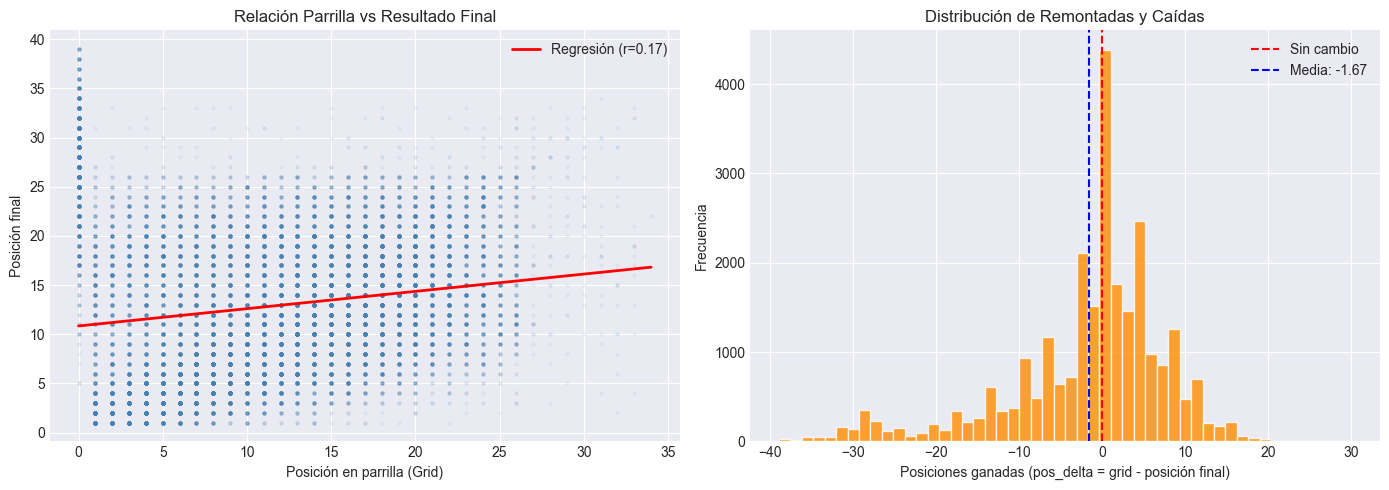


Remontada media por carrera: -1.67 posiciones


In [10]:
# Eliminar NaN para el cálculo
mask_valid = (~np.isnan(grid)) & (~np.isnan(pos))
grid_v = grid[mask_valid]
pos_v  = pos[mask_valid]

# Correlación con NumPy
corr_matrix = np.corrcoef(grid_v, pos_v)
correlacion = corr_matrix[0, 1]

print(f"Correlación Pearson (Grid → Posición final): {correlacion:.4f}")
print()
if correlacion > 0.7:
    interpretacion = "MUY ALTA — Salir adelante es determinante para ganar"
elif correlacion > 0.5:
    interpretacion = "ALTA — La parrilla influye significativamente"
elif correlacion > 0.3:
    interpretacion = "MODERADA — La parrilla influye pero no es determinante"
else:
    interpretacion = "BAJA — La parrilla tiene poca influencia"
print(f"Interpretación: {interpretacion}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(grid_v, pos_v, alpha=0.05, color='steelblue', s=5)
m, b = np.polyfit(grid_v, pos_v, 1)
x_line = np.linspace(grid_v.min(), grid_v.max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Regresión (r={correlacion:.2f})')
ax.set_xlabel("Posición en parrilla (Grid)")
ax.set_ylabel("Posición final")
ax.set_title("Relación Parrilla vs Resultado Final")
ax.legend()

# Histograma
ax = axes[1]
delta_v = delta[mask_valid]
ax.hist(delta_v, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Sin cambio')
ax.axvline(np.mean(delta_v), color='blue', linestyle='--', linewidth=1.5, 
           label=f'Media: {np.mean(delta_v):.2f}')
ax.set_xlabel("Posiciones ganadas (pos_delta = grid - posición final)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de Remontadas y Caídas")
ax.legend()

plt.tight_layout()
plt.show()
print(f"\nRemontada media por carrera: {np.mean(delta_v):.2f} posiciones")

## 2.3 Distribución de Puntos y Análisis de Percentiles

Se analiza cómo se distribuyen los puntos entre los pilotos y qué porcentaje del total acumula cada decil.

Carreras totales analizadas:         26,668
Entradas con puntos (> 0):            8,142 (30.5%)
Puntos promedio por entrada:           1.99
Puntos promedio cuando puntúan:        6.52

Percentiles de distribución de puntos:
  P10: 0.0 puntos
  P25: 0.0 puntos
  P50: 0.0 puntos
  P75: 2.0 puntos
  P90: 8.0 puntos
  P95: 10.0 puntos
  P99: 25.0 puntos


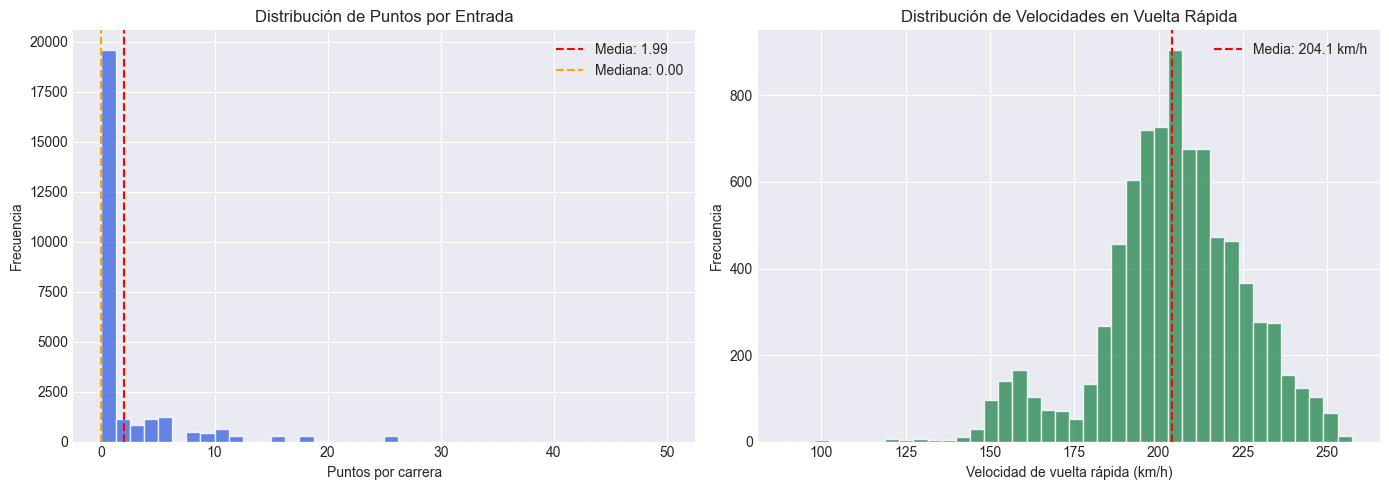

In [11]:
# DISTRIBUCIÓN DE PUNTOS 

# Solo entradas con puntos
pts_positivos = pts[pts > 0]

print(f"Carreras totales analizadas:       {len(pts):>8,}")
print(f"Entradas con puntos (> 0):         {len(pts_positivos):>8,} ({len(pts_positivos)/len(pts)*100:.1f}%)")
print(f"Puntos promedio por entrada:       {np.mean(pts):>8.2f}")
print(f"Puntos promedio cuando puntúan:    {np.mean(pts_positivos):>8.2f}")
print()

# Percentiles de puntos
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("Percentiles de distribución de puntos:")
for p in percentiles:
    val = np.percentile(pts, p)
    print(f"  P{p:>2}: {val:.1f} puntos")

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(pts, bins=40, color='royalblue', edgecolor='white', alpha=0.8)
ax.set_xlabel("Puntos por carrera")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de Puntos por Entrada")
ax.axvline(np.mean(pts), color='red', linestyle='--', label=f'Media: {np.mean(pts):.2f}')
ax.axvline(np.median(pts), color='orange', linestyle='--', label=f'Mediana: {np.median(pts):.2f}')
ax.legend()

# Velocidades
ax = axes[1]
ax.hist(speed, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(speed), color='red', linestyle='--', label=f'Media: {np.mean(speed):.1f} km/h')
ax.set_xlabel("Velocidad de vuelta rápida (km/h)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de Velocidades en Vuelta Rápida")
ax.legend()

plt.tight_layout()
plt.show()

## 2.4 Estadísticas Comparativas por Status de Carrera

Se compara el rendimiento medio entre pilotos que terminaron la carrera y los que abandonaron.

Métrica                     Finished        DNF
  Nº de entradas             7656.00   19012.00
  Media puntos                  6.40       0.22
  Mediana posición              4.00      16.00
  % del total                  28.71      71.29


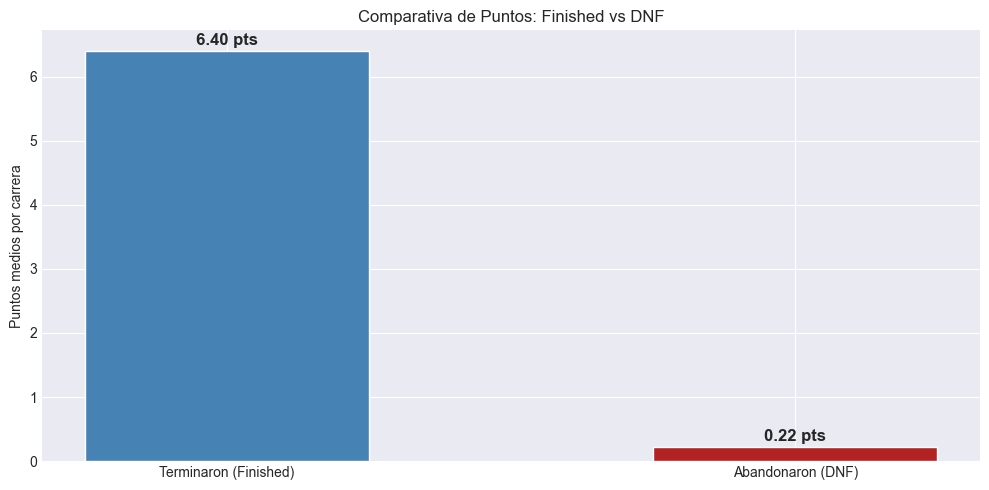

In [12]:
# ANÁLISIS POR STATUS 

# Máscaras NumPy
mask_finished = df['statusId'].values == 1
mask_dnf      = df['statusId'].values != 1

pts_finished = pts[mask_finished]
pts_dnf      = pts[mask_dnf]
pos_finished = pos[mask_finished]
pos_dnf      = pos[mask_dnf]

print("="*50)
print(f"{'Métrica':<25} {'Finished':>10} {'DNF':>10}")
print("="*50)
metricas = [
    ('Nº de entradas',  len(pts_finished),               len(pts_dnf)),
    ('Media puntos',    np.mean(pts_finished),            np.mean(pts_dnf)),
    ('Mediana posición', np.median(pos_finished),         np.median(pos_dnf)),
    ('% del total',     len(pts_finished)/len(pts)*100,  len(pts_dnf)/len(pts)*100),
]
for label, v1, v2 in metricas:
    print(f"  {label:<23} {v1:>10.2f} {v2:>10.2f}")
print("="*50)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
labels  = ['Terminaron (Finished)', 'Abandonaron (DNF)']
medias  = [np.mean(pts_finished), np.mean(pts_dnf)]
colores = ['steelblue', 'firebrick']
bars = ax.bar(labels, medias, color=colores, width=0.5, edgecolor='white')
for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f} pts', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel("Puntos medios por carrera")
ax.set_title("Comparativa de Puntos: Finished vs DNF")
plt.tight_layout()
plt.show()

---

#  FASE 3: Análisis Avanzado con Pandas

En esta fase se aplican las capacidades avanzadas de **Pandas**: `groupby`, `merge`, `pivot_table`, `apply`, operaciones con series temporales y más.

### Objetivos:
- Analizar el rendimiento histórico de pilotos y constructores
- Estudiar la evolución de la dominancia por décadas
- Calcular métricas compuestas de consistencia, fiabilidad y rendimiento
- Generar visualizaciones completas para cada análisis

## 3.1 Equipos con Más Abandonos

Los abandonos tienen un impacto directo en el campeonato de constructores. Se analiza qué equipos han sufrido más problemas de fiabilidad a lo largo de la historia.

Top 15 Equipos por Número de Abandonos:


,constructor_name,abandonos,total,pct_abandono
0,Ferrari,1102,2417,45.60
1,Williams,943,1676,56.30
2,McLaren,932,1923,48.50
3,Tyrrell,741,881,84.10
4,Team Lotus,693,871,79.60
5,Minardi,667,672,99.30
6,Sauber,641,837,76.60
7,Arrows,553,590,93.70
8,Ligier,540,611,88.40
9,Brabham,540,662,81.60


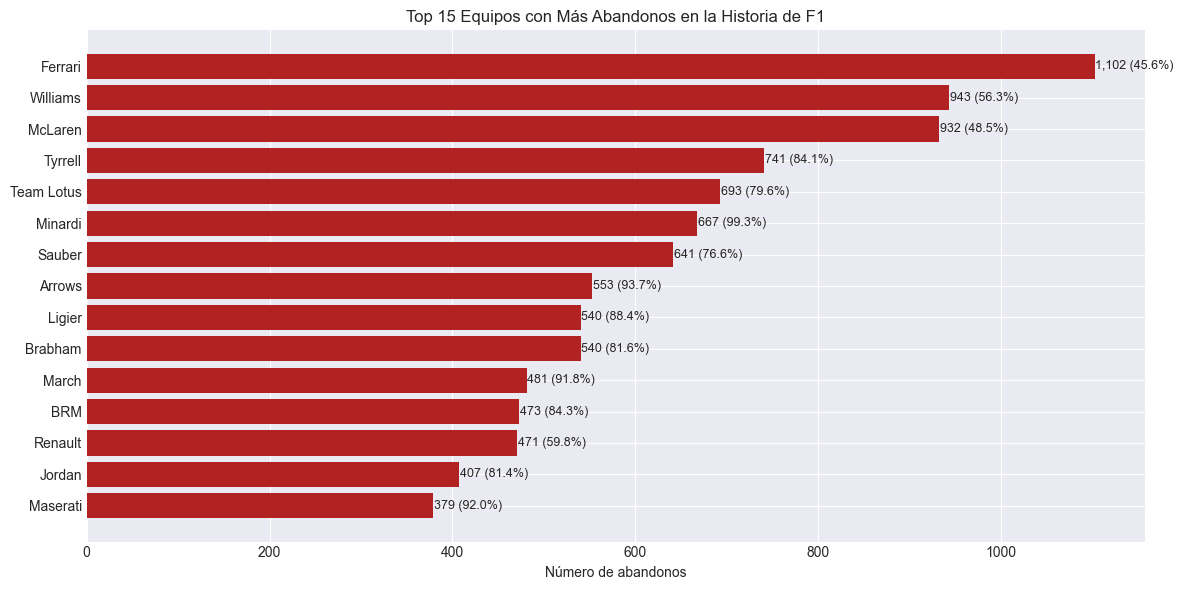

In [13]:
#3.1 EQUIPOS CON MÁS ABANDONOS
aband_equipos = (
    df[df['dnf'] == 1]
    .groupby('constructor_name')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='abandonos')
)

# Número total de participaciones por equipo
total_participaciones = (
    df.groupby('constructor_name')
    .size()
    .reset_index(name='total')
)

aband_equipos = aband_equipos.merge(total_participaciones, on='constructor_name')
aband_equipos['pct_abandono'] = (aband_equipos['abandonos'] / aband_equipos['total'] * 100).round(1)

print("Top 15 Equipos por Número de Abandonos:")
display(aband_equipos)

plt.figure(figsize=(12, 6))
bars = plt.barh(aband_equipos['constructor_name'], aband_equipos['abandonos'], color='firebrick')
for bar, row in zip(bars, aband_equipos.itertuples()):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row.abandonos:,} ({row.pct_abandono}%)', va='center', fontsize=9)
plt.xlabel("Número de abandonos")
plt.title("Top 15 Equipos con Más Abandonos en la Historia de F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.2 Porcentaje de Abandono por Piloto

Se calcula el porcentaje de carreras en las que cada piloto no terminó la carrera, aqui se refleja tanto la fiabilidad del coche como situaciones de accidente.

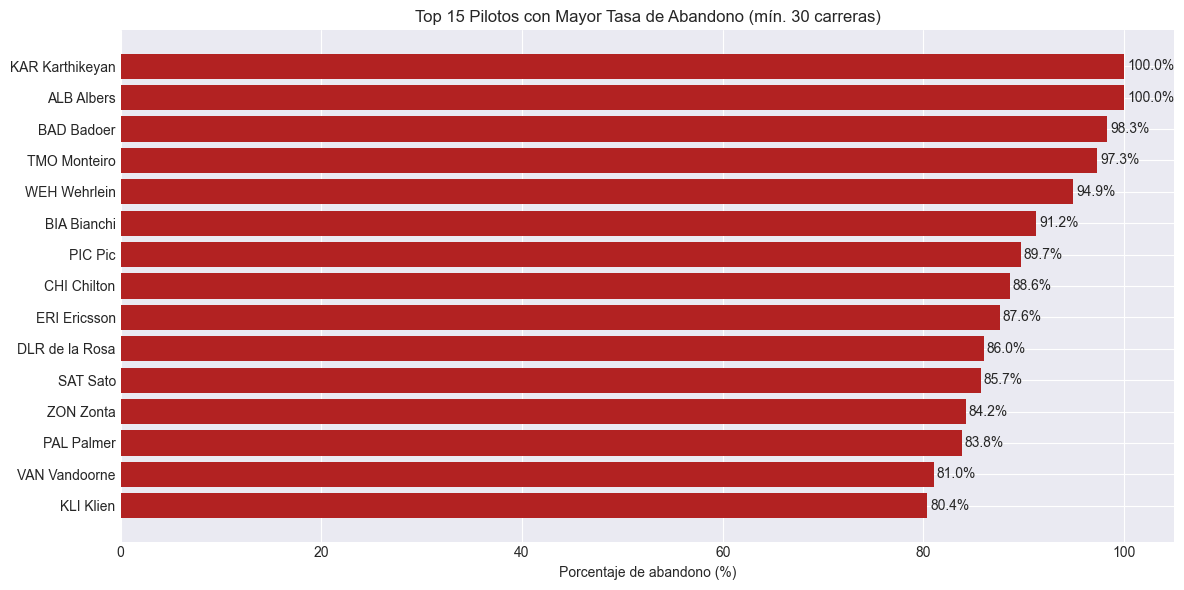

In [14]:
#3.2 PORCENTAJE DE ABANDONO POR PILOTO 

# Solo pilotos con al menos 30 carreras disputadas porque hay muchos que entran como suplentes
carreras_piloto = df.groupby(['driverId', 'code', 'surname']).size().reset_index(name='total')
carreras_piloto = carreras_piloto[carreras_piloto['total'] >= 30]

dnf_piloto = (
    df[df['dnf'] == 1]
    .groupby(['driverId', 'code', 'surname'])
    .size()
    .reset_index(name='dnf_count')
)

aband_pilotos = (
    carreras_piloto
    .merge(dnf_piloto, on=['driverId', 'code', 'surname'], how='left')
)
aband_pilotos['dnf_count'] = aband_pilotos['dnf_count'].fillna(0)
aband_pilotos['porcentaje_abandono'] = (aband_pilotos['dnf_count'] / aband_pilotos['total'] * 100).round(1)
aband_pilotos = aband_pilotos.sort_values('porcentaje_abandono', ascending=False)

top_aband = aband_pilotos.head(15).copy()
top_aband['piloto'] = top_aband['code'] + ' ' + top_aband['surname']

plt.figure(figsize=(12, 6))
bars = plt.barh(top_aband['piloto'], top_aband['porcentaje_abandono'], color='firebrick')
for bar, val in zip(bars, top_aband['porcentaje_abandono']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.xlabel("Porcentaje de abandono (%)")
plt.title("Top 15 Pilotos con Mayor Tasa de Abandono (mín. 30 carreras)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.3 Porcentaje de Victorias por Piloto (Win Rate)

El porcentaje de victorias sobre el total de carreras disputadas esto se ajusta mas que el conteo absoluto de victorias, ya que normaliza por el número de participaciones.

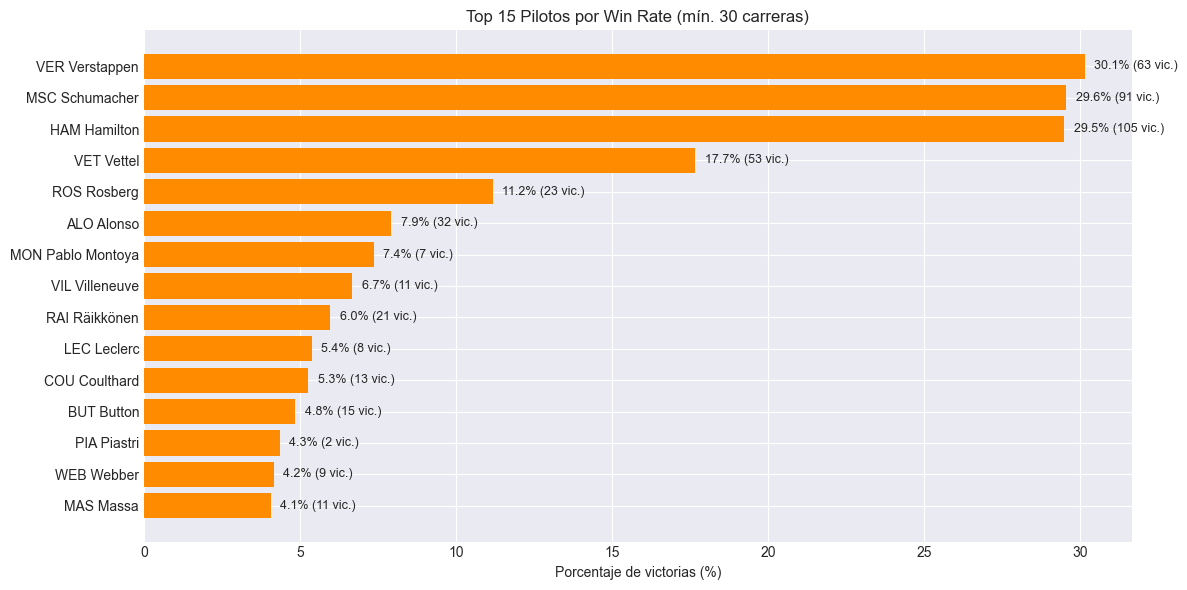

In [15]:
# 3.3 WIN RATE POR PILOTO 

victorias = (
    df[df['positionOrder'] == 1]
    .groupby(['driverId', 'code', 'surname'])
    .size()
    .reset_index(name='wins')
)

# Solo pilotos con al menos 30 carreras disputadas porque hay muchos que entran como suplentes
total_carreras = carreras_piloto[['driverId', 'code', 'surname', 'total']]

win_rate = (
    victorias
    .merge(total_carreras, on=['driverId', 'code', 'surname'])
)
win_rate['win_rate'] = (win_rate['wins'] / win_rate['total'] * 100).round(2)
win_rate = win_rate.sort_values('win_rate', ascending=False)

top_winrate = win_rate.head(15).copy()
top_winrate['piloto'] = top_winrate['code'] + ' ' + top_winrate['surname']

plt.figure(figsize=(12, 6))
bars = plt.barh(top_winrate['piloto'], top_winrate['win_rate'], color='darkorange')
for bar, row in zip(bars, top_winrate.itertuples()):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{row.win_rate:.1f}% ({row.wins} vic.)', va='center', fontsize=9)
plt.xlabel("Porcentaje de victorias (%)")
plt.title("Top 15 Pilotos por Win Rate (mín. 30 carreras)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.4 Probabilidad Histórica de Ganar el Campeonato

Aqui se identifica al campeón de cada temporada y se calcula la probabilidad de ganar el campeonato para cada piloto activo.

,forename,surname,temporadas,campeonatos,prob_campeonato
7,Max,Verstappen,10,4,40.00
0,Lewis,Hamilton,18,7,38.90
1,Fernando,Alonso,21,2,9.50
3,Sergio,Pérez,14,0,0.00
2,Nico,Hülkenberg,13,0,0.00
4,Daniel,Ricciardo,14,0,0.00
5,Valtteri,Bottas,12,0,0.00
6,Kevin,Magnussen,10,0,0.00
8,Carlos,Sainz,10,0,0.00
9,Esteban,Ocon,8,0,0.00


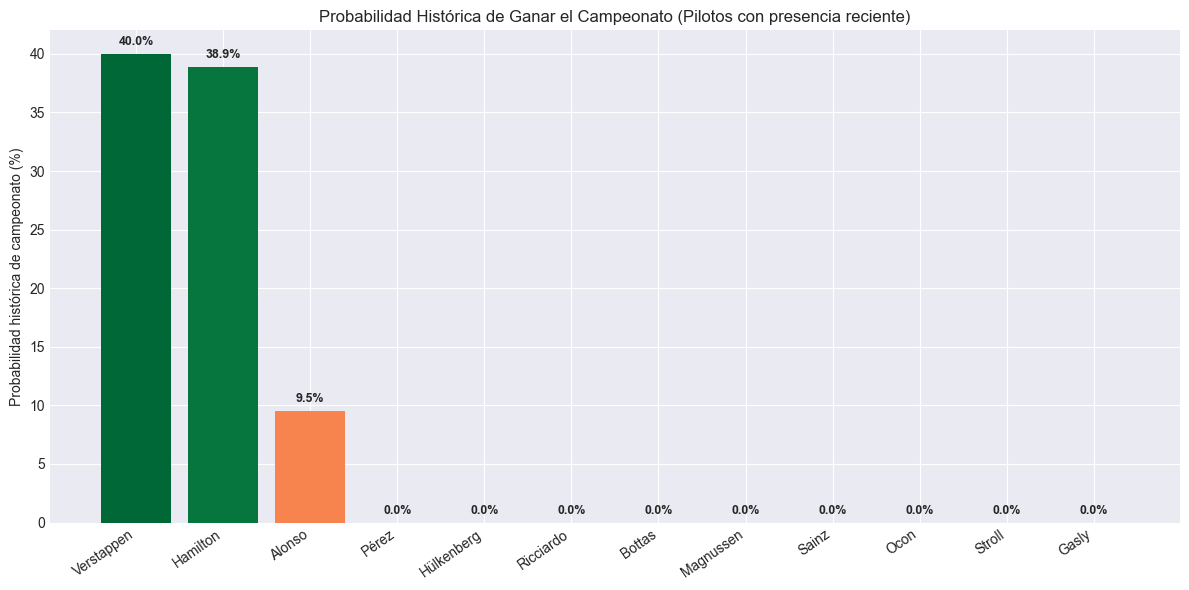

In [16]:
#3.4 PROBABILIDAD HISTÓRICA DE CAMPEONATO 

# Puntos totales por piloto y temporada
puntos_temporada = (
    df.groupby(['year', 'driverId', 'forename', 'surname'])['points']
    .sum()
    .reset_index()
)

# Campeón por año
campeones = (
    puntos_temporada
    .sort_values(['year', 'points'], ascending=[True, False])
    .groupby('year')
    .first()
    .reset_index()
)

# Pilotos activos los que participaron en 2022 o después
pilotos_activos_ids = df[df['year'] >= 2023]['driverId'].unique()

# Veces campeón
veces_campeon = (
    campeones[campeones['driverId'].isin(pilotos_activos_ids)]
    .groupby(['driverId', 'forename', 'surname'])
    .size()
    .reset_index(name='campeonatos')
)

# Temporadas disputadas
temporadas_disputadas = (
    df[df['driverId'].isin(pilotos_activos_ids)]
    .groupby(['driverId', 'forename', 'surname'])['year']
    .nunique()
    .reset_index(name='temporadas')
)

tabla_prob = temporadas_disputadas.merge(veces_campeon, on=['driverId', 'forename', 'surname'], how='left')
tabla_prob['campeonatos'] = tabla_prob['campeonatos'].fillna(0).astype(int)
tabla_prob['prob_campeonato'] = (tabla_prob['campeonatos'] / tabla_prob['temporadas'] * 100).round(1)
tabla_prob = tabla_prob.sort_values('prob_campeonato', ascending=False)

display(tabla_prob[['forename', 'surname', 'temporadas', 'campeonatos', 'prob_campeonato']].head(15))

# Gráfico
top_prob = tabla_prob.head(12)
plt.figure(figsize=(12, 6))
bars = plt.bar(top_prob['surname'], top_prob['prob_campeonato'], 
               color=plt.cm.RdYlGn(top_prob['prob_campeonato']/top_prob['prob_campeonato'].max()))
for bar, val in zip(bars, top_prob['prob_campeonato']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.ylabel("Probabilidad histórica de campeonato (%)")
plt.title("Probabilidad Histórica de Ganar el Campeonato (Pilotos con presencia reciente)")
plt.tight_layout()
plt.show()

## 3.5 Pilotos Más Consistentes

La consistencia se mide como la desviación estándar de la posición final: cuanto menor sea, más regularmente el piloto termina en posiciones similares. Se analiza solo entre los pilotos con más victorias.

,piloto,wins,std_pos
0,MAS Massa,11,5.52
1,HAM Hamilton,105,5.55
2,VIL Villeneuve,11,5.70
3,LEC Leclerc,8,5.99
4,VER Verstappen,63,6.00
5,BOT Bottas,10,6.00
6,BUT Button,15,6.00
7,ALO Alonso,32,6.04
8,RAI Räikkönen,21,6.17
9,ROS Rosberg,23,6.25


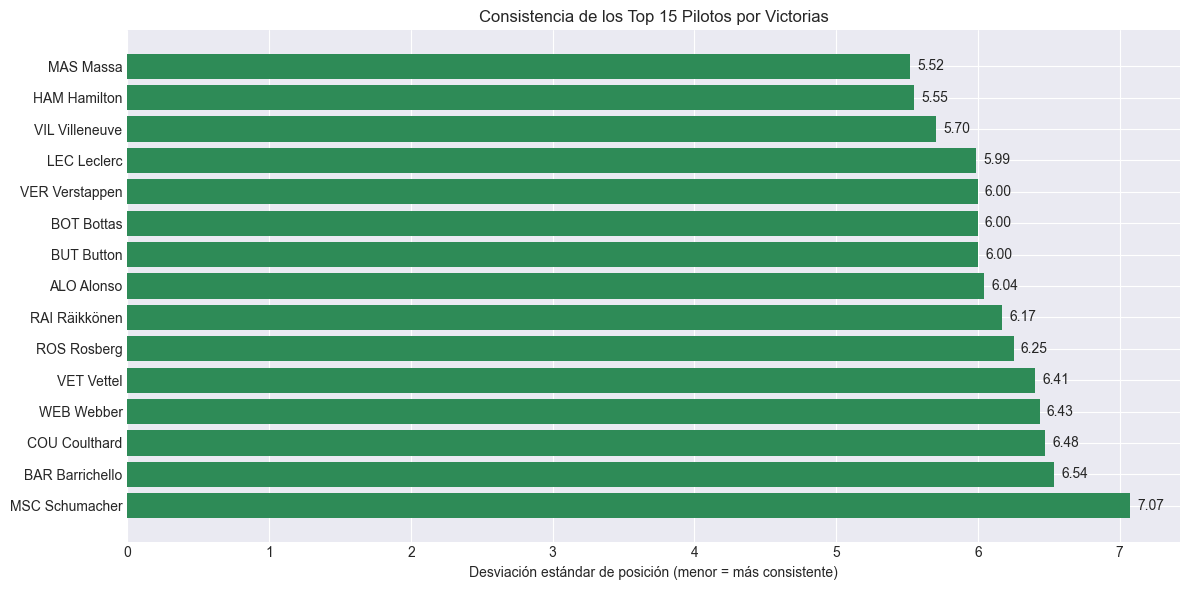

In [17]:
# ── 3.5 CONSISTENCIA DE LOS MEJORES PILOTOS ─────────────────────────────

top_ganadores_ids = victorias.sort_values('wins', ascending=False).head(15)['driverId']

consistencia = (
    df[df['driverId'].isin(top_ganadores_ids)]
    .groupby(['driverId', 'code', 'surname'])['positionOrder']
    .std()
    .reset_index(name='std_pos')
    .sort_values('std_pos')
)

consistencia = consistencia.merge(
    victorias[['driverId', 'wins']], on='driverId', how='left'
)
consistencia['piloto'] = consistencia['code'] + ' ' + consistencia['surname']

display(consistencia[['piloto', 'wins', 'std_pos']].round(2))

plt.figure(figsize=(12, 6))
bars = plt.barh(consistencia['piloto'], consistencia['std_pos'], color='seagreen')
for bar, row in zip(bars, consistencia.itertuples()):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{row.std_pos:.2f}', va='center', fontsize=10)
plt.xlabel("Desviación estándar de posición (menor = más consistente)")
plt.title("Consistencia de los Top 15 Pilotos por Victorias")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.6 Top Constructores por Puntos Totales

Se analiza el rendimiento histórico de los constructores considerando puntos totales, victorias, posición media y consistencia.

,constructorId,constructor_name,total_points,carreras,avg_pos,wins
0,6,Ferrari,11059.44,2417,8.29,248
1,131,Mercedes,7728.64,650,5.98,129
2,9,Red Bull,7673.00,788,7.35,122
3,1,McLaren,7022.50,1923,9.50,185
4,3,Williams,3641.00,1676,11.10,114
5,4,Renault,1777.00,787,11.17,35
6,10,Force India,1098.00,424,11.69,0
7,32,Team Lotus,995.00,871,13.06,45
8,22,Benetton,861.50,520,10.16,27
9,25,Tyrrell,711.00,881,13.16,23


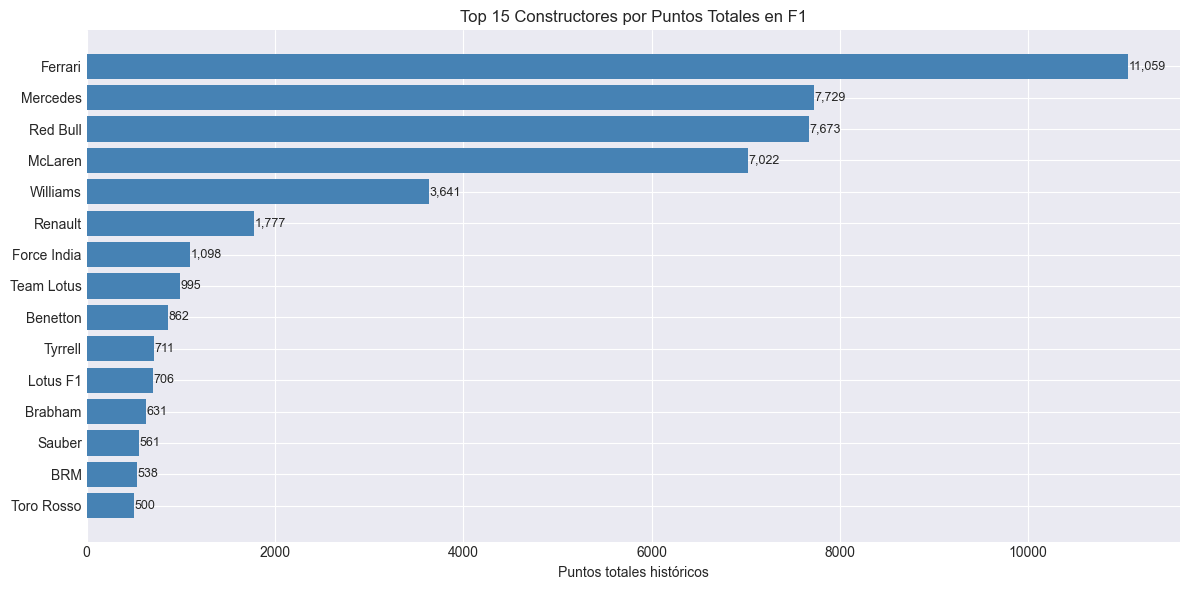

In [18]:
# ── 3.6 TOP CONSTRUCTORES ────────────────────────────────────────────────

top_constructors = (
    df.groupby(['constructorId', 'constructor_name'])
    .agg(
        total_points=('points', 'sum'),
        carreras=('resultId', 'count'),
        avg_pos=('positionOrder', 'mean'),
        wins=('positionOrder', lambda x: (x == 1).sum())
    )
    .sort_values('total_points', ascending=False)
    .reset_index()
)

display(top_constructors.head(15).round(2))

plt.figure(figsize=(12, 6))
tc15 = top_constructors.head(15)
bars = plt.barh(tc15['constructor_name'], tc15['total_points'], color='steelblue')
for bar, val in zip(bars, tc15['total_points']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)
plt.xlabel("Puntos totales históricos")
plt.title("Top 15 Constructores por Puntos Totales en F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.7 Dominancia por Década

Se analiza qué constructores han dominado cada década de la Fórmula 1, revelando la dominancia que marcan cada epoca de la f1.

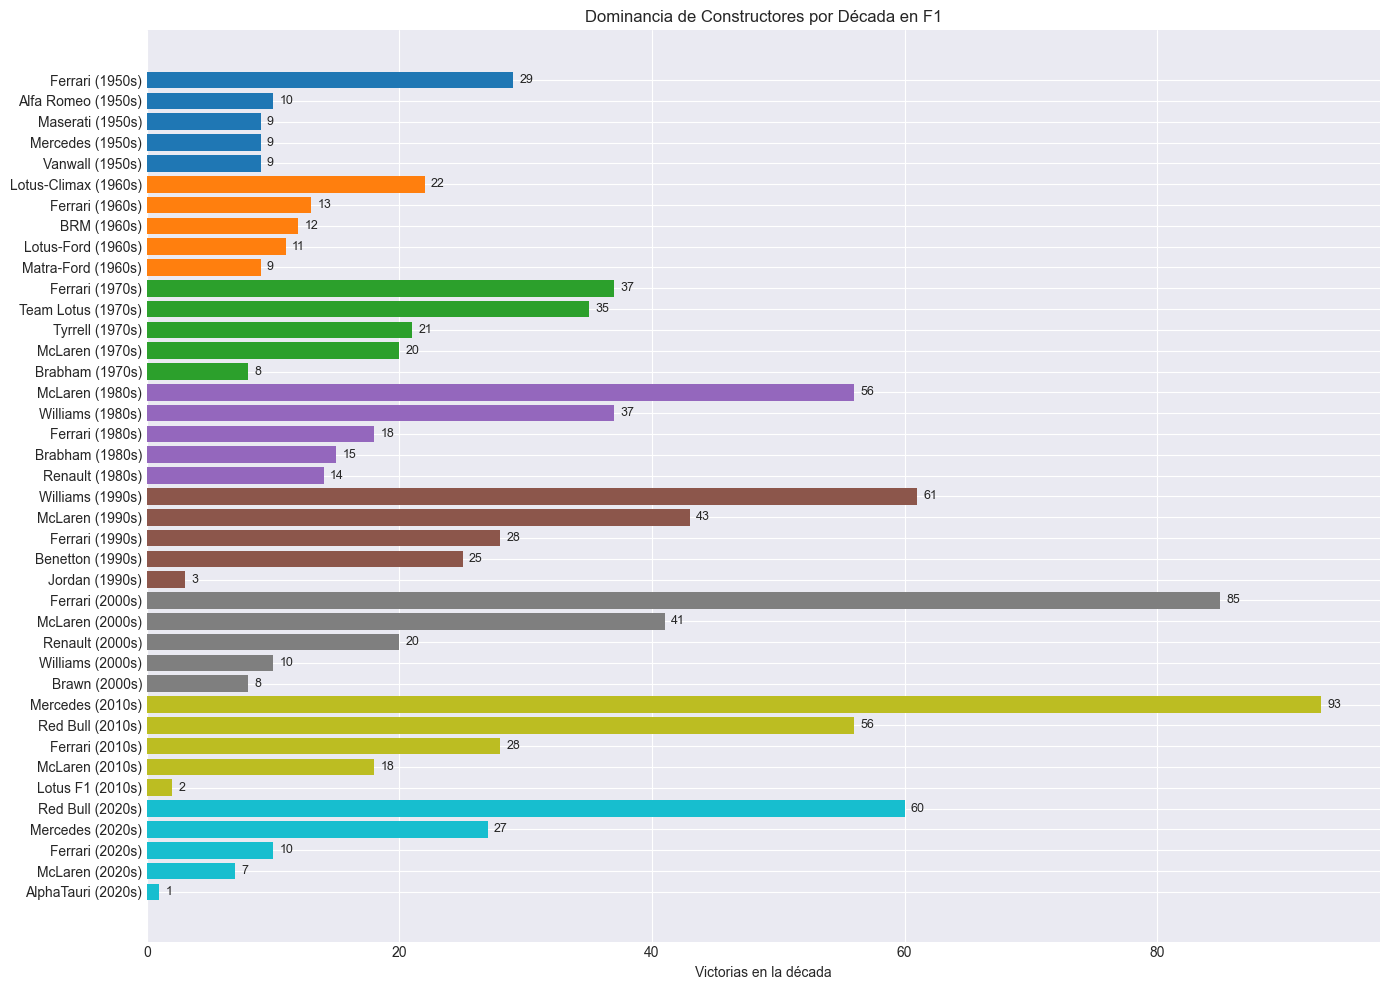


Equipo más dominante por década:


,decada,equipo_dominante,victorias_lider
0,1950,Ferrari,29
1,1960,Lotus-Climax,22
2,1970,Ferrari,37
3,1980,McLaren,56
4,1990,Williams,61
5,2000,Ferrari,85
6,2010,Mercedes,93
7,2020,Red Bull,60


In [19]:
# ── 3.7 DOMINANCIA POR DÉCADA ────────────────────────────────────────────

import matplotlib.cm as cm
import matplotlib.colors as mcolors

df['decada'] = (df['year'].astype(int) // 10) * 10

dominancia = (
    df[df['positionOrder'] == 1]
    .groupby(['decada', 'constructor_name'])
    .size()
    .reset_index(name='victorias')
)

top_por_decada = (
    dominancia
    .sort_values(['decada', 'victorias'], ascending=[True, False])
    .groupby('decada')
    .head(5)
    .copy()
)

top_por_decada['etiqueta'] = (top_por_decada['constructor_name'] + 
                               ' (' + top_por_decada['decada'].astype(str) + 's)')

decadas = sorted(top_por_decada['decada'].unique())
colores_decada = cm.get_cmap('tab10', len(decadas))
color_map = {d: mcolors.rgb2hex(colores_decada(i)) for i, d in enumerate(decadas)}
top_por_decada['color'] = top_por_decada['decada'].map(color_map)

plt.figure(figsize=(14, 10))
bars = plt.barh(top_por_decada['etiqueta'], top_por_decada['victorias'],
                color=top_por_decada['color'])
for bar, val in zip(bars, top_por_decada['victorias']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.xlabel("Victorias en la década")
plt.title("Dominancia de Constructores por Década en F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tabla resumen
dominancia_decada = (
    dominancia.sort_values(['decada', 'victorias'], ascending=[True, False])
    .groupby('decada').first().reset_index()
    .rename(columns={'constructor_name': 'equipo_dominante', 'victorias': 'victorias_lider'})
)
print("\nEquipo más dominante por década:")
display(dominancia_decada)

## 3.8 Remontadas Extremas

Se identifican las remontadas más espectaculares de la historia los casos donde un piloto salió desde muy atrás en la parrilla y terminó en una posición muy adelantada.

Top 20 Remontadas más Espectaculares:


,code,surname,constructor_name,year,grid,positionOrder,pos_delta
0,NaN,Rathmann,Epperly,1957,32,2,30
1,NaN,Thomson,Kuzma,1955,33,4,29
2,NaN,Linden,Sherman,1951,31,4,27
3,NaN,Russo,Kurtis Kraft,1954,32,8,24
4,NaN,Ball,Schroeder,1951,29,5,24
5,NaN,Goldsmith,Epperly,1960,26,3,23
6,NaN,Cheesbourg,Kurtis Kraft,1958,33,10,23
7,NaN,Freeland,Phillips,1956,26,3,23
8,NaN,Amick,Epperly,1958,25,2,23
9,NaN,Peterson,March,1972,26,4,22


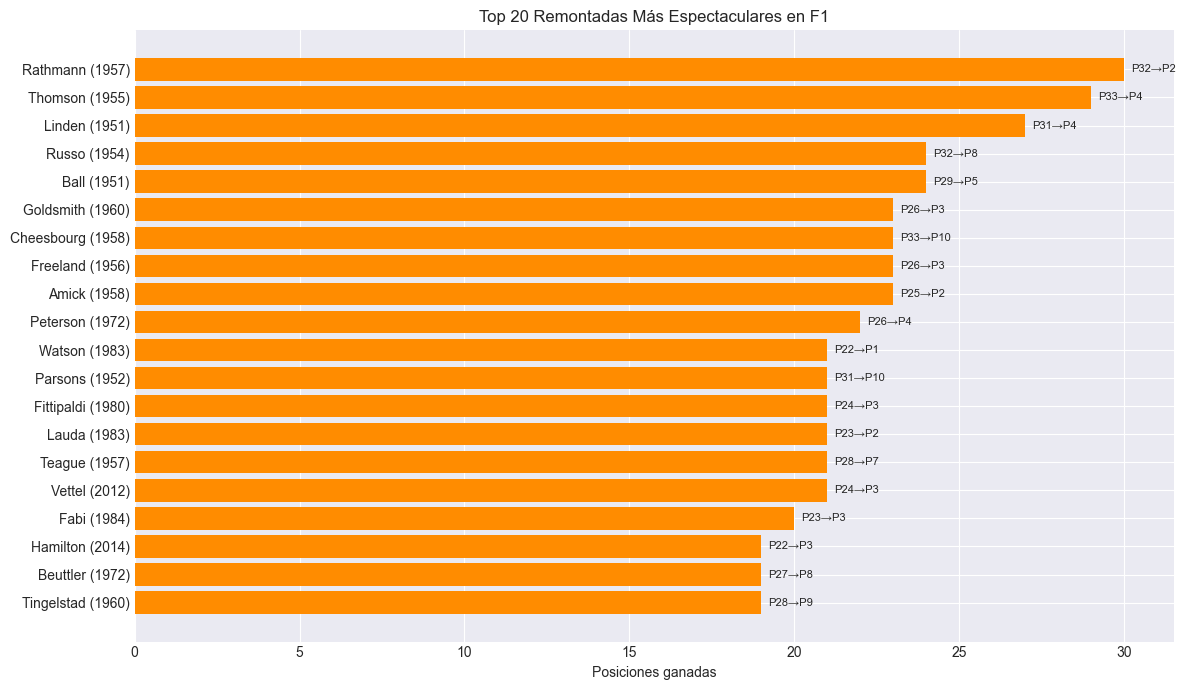

In [ ]:
# 3.8 REMONTADAS EXTREMAS

# Solo considerar carreras donde el piloto termina la carrera
remontadas_df = df[(df['dnf'] == 0) & (df['grid'] > 1)].copy()
remontadas = remontadas_df.sort_values('pos_delta', ascending=False).head(20)

print("Top 20 Remontadas más Espectaculares:")
display(remontadas[['code', 'surname', 'constructor_name', 'year', 'grid', 
                     'positionOrder', 'pos_delta']].reset_index(drop=True))

plt.figure(figsize=(12, 7))
etiquetas = remontadas['surname'] + ' (' + remontadas['year'].astype(str) + ')'
bars = plt.barh(etiquetas, remontadas['pos_delta'], color='darkorange')
for bar, row in zip(bars, remontadas.itertuples()):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'P{int(row.grid)}→P{int(row.positionOrder)}', va='center', fontsize=8)
plt.xlabel("Posiciones ganadas")
plt.title("Top 20 Remontadas Más Espectaculares en F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.9 Pilotos con Más Vueltas Rápidas

La vuelta rápida es un indicador de la velocidad pura del piloto y del coche. Se analizan los pilotos más frecuentes en este logro.

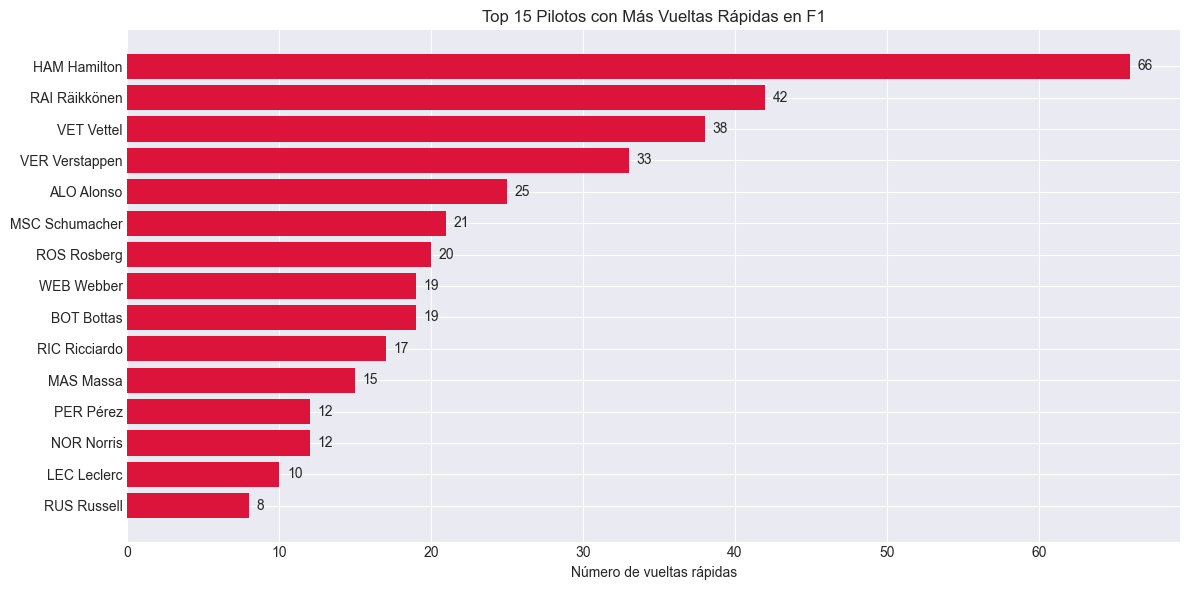

In [ ]:
#3.9 PILOTOS CON MÁS VUELTAS RÁPIDAS

df['rank_num'] = pd.to_numeric(df['rank'], errors='coerce')

fastest = (
    df[df['rank_num'] == 1]
    .groupby(['driverId', 'code', 'surname'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='fastest_laps')
)

top_fastest = fastest.head(15).copy()
top_fastest['piloto'] = top_fastest['code'] + ' ' + top_fastest['surname']

plt.figure(figsize=(12, 6))
bars = plt.barh(top_fastest['piloto'], top_fastest['fastest_laps'], color='crimson')
for bar, val in zip(bars, top_fastest['fastest_laps']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=10)
plt.xlabel("Número de vueltas rápidas")
plt.title("Top 15 Pilotos con Más Vueltas Rápidas en F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.10 Equipos con Mejor Ritmo de Carrera

El ritmo medio de carrera se mide como la velocidad media en vuelta rápida promediada por cada equipo. Es un indicador del potencial técnico del coche.

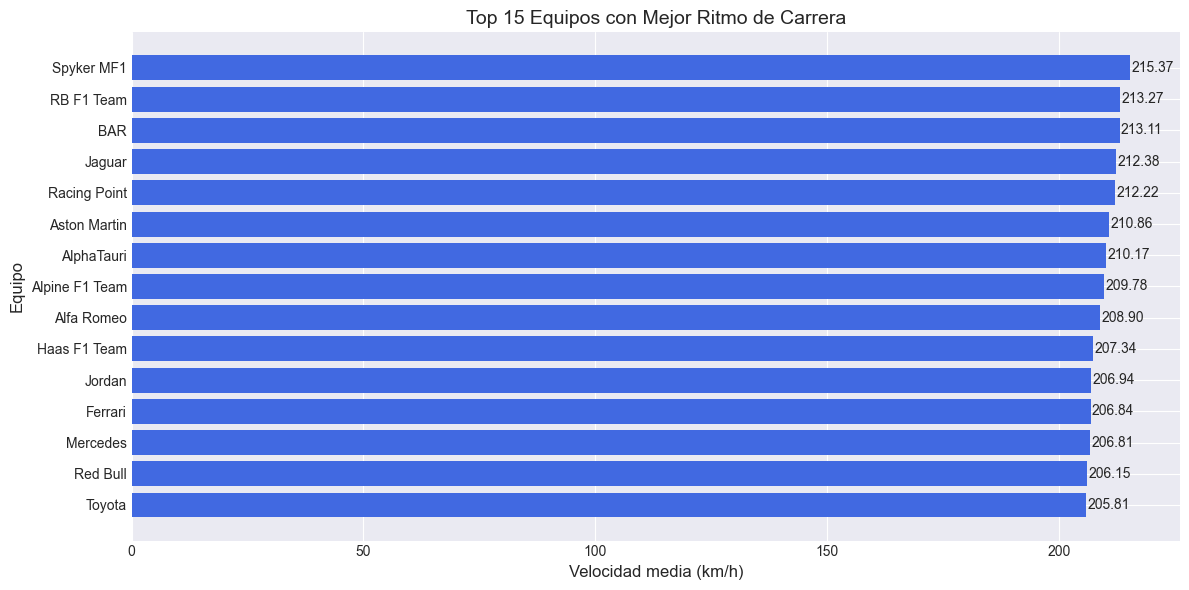

In [ ]:
# 3.10 EQUIPOS CON MEJOR RITMO DE CARRERA 

df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')

ritmo = (
    df.groupby('constructor_name')['fastestLapSpeed']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_ritmo = ritmo.head(15)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_ritmo['constructor_name'],
    top_ritmo['fastestLapSpeed'],
    color='royalblue'
)

for bar, valor in zip(bars, top_ritmo['fastestLapSpeed']):
    plt.text(valor + 0.3, bar.get_y() + bar.get_height()/2,
             f"{valor:.2f}", va='center', fontsize=10)

plt.xlabel("Velocidad media (km/h)", fontsize=12)
plt.ylabel("Equipo", fontsize=12)
plt.title("Top 15 Equipos con Mejor Ritmo de Carrera", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---

#  FASE 4: Insights y Conclusiones

En esta fase se responden las 4 preguntas clave de análisis, integrando todos los indicadores calculados en las fases anteriores. Finalmente se presenta un panel con el resumen con los 9 gráficos más relevantes.

### Preguntas de Análisis:
1. ¿Qué pilotos han sido realmente los más dominantes?
2. ¿Qué equipos combinan mejor rendimiento, fiabilidad y consistencia?
3. ¿Cómo ha cambiado la dominancia a lo largo de las décadas?
4. ¿Qué pilotos destacan por sus remontadas extremas?

## 4.1 Pregunta 1: ¿Qué pilotos han sido realmente los más dominantes?

Para responder esta pregunta de forma objetiva, se crea un **índice de dominancia compuesto** que integra tres dimensiones:
- **Victorias totales**: volumen absoluto de triunfos
- **Win Rate (%)**: victorias relativas al número de participaciones
- **Consistencia (std)**: regularidad en las posiciones finales

In [23]:
#4.1 PILOTOS MÁS DOMINANTES

victorias_pilotos = (
    df[df['positionOrder'] == 1]
    .groupby(['driverId', 'code', 'surname'])
    .size()
    .reset_index(name='wins')
)

wr = win_rate[['driverId', 'code', 'surname', 'win_rate', 'total']].copy()

cons_all = (
    df.groupby(['driverId', 'code', 'surname'])['positionOrder']
    .std()
    .reset_index(name='std_pos')
)

dominancia_pilotos = (
    victorias_pilotos
    .merge(wr, on=['driverId', 'code', 'surname'])
    .merge(cons_all, on=['driverId', 'code', 'surname'])
    .query('total >= 30')
)

for col, asc in [('wins', False), ('win_rate', False), ('std_pos', True)]:
    mn, mx = dominancia_pilotos[col].min(), dominancia_pilotos[col].max()
    if asc:
        dominancia_pilotos[f'{col}_norm'] = (mx - dominancia_pilotos[col]) / (mx - mn) * 100
    else:
        dominancia_pilotos[f'{col}_norm'] = (dominancia_pilotos[col] - mn) / (mx - mn) * 100

dominancia_pilotos['indice_dominancia'] = (
    dominancia_pilotos['wins_norm'] * 0.4 +
    dominancia_pilotos['win_rate_norm'] * 0.35 +
    dominancia_pilotos['std_pos_norm'] * 0.25
).round(1)

dominancia_pilotos = dominancia_pilotos.sort_values('indice_dominancia', ascending=False)

print("TOP 15 PILOTOS MÁS DOMINANTES (Índice compuesto):")
display(dominancia_pilotos[['code', 'surname', 'wins', 'win_rate', 'std_pos', 'indice_dominancia']].head(15).round(2))

TOP 15 PILOTOS MÁS DOMINANTES (Índice compuesto):


,code,surname,wins,win_rate,std_pos,indice_dominancia
0,HAM,Hamilton,105,29.49,5.55,89.70
22,VER,Verstappen,63,30.14,6.00,69.80
15,MSC,Schumacher,91,29.55,7.07,68.90
11,VET,Vettel,53,17.67,6.41,47.10
2,ALO,Alonso,32,7.92,6.04,31.20
1,ROS,Rosberg,23,11.17,6.25,29.50
18,MAL,Maldonado,1,1.04,4.61,25.80
27,NOR,Norris,4,3.12,4.98,25.70
17,VIL,Villeneuve,11,6.67,5.70,25.10
25,GAS,Gasly,1,0.65,4.69,24.50


###  Respuesta a la Pregunta 1

>Los pilotos más dominantes son aquellos que combinan muchas victorias absolutas, un alto porcentaje de victorias
> El índice compuesto revela que los grandes campeones no solo ganan con frecuencia, sino que siempre están en los puntos si no que esta regularidad es lo que distingue a un campeón de un piloto rápido ocasional.

## 4.2 Pregunta 2: ¿Qué equipos combinan mejor rendimiento, fiabilidad y consistencia?

Se construye un resumen de rendimiento de equipos con cinco dimensiones: puntos totales, victorias, ritmo de carrera, consistencia y fiabilidad.

In [24]:
#4.2 RESUMEN TRIANGULAR DE EQUIPOS

puntos_eq = df.groupby('constructor_name')['points'].sum().reset_index(name='total_points')
wins_eq   = df[df['positionOrder']==1].groupby('constructor_name').size().reset_index(name='wins')
ritmo_eq  = (df.dropna(subset=['fastestLapSpeed'])
               .groupby('constructor_name')['fastestLapSpeed'].mean().reset_index(name='avg_speed'))
cons_eq   = df.groupby('constructor_name')['positionOrder'].std().reset_index(name='std_pos')
aband_eq  = df[df['dnf']==1].groupby('constructor_name').size().reset_index(name='abandonos')
total_eq  = df.groupby('constructor_name').size().reset_index(name='total')

equipos_resumen = (
    puntos_eq
    .merge(wins_eq,  on='constructor_name', how='left')
    .merge(ritmo_eq, on='constructor_name', how='left')
    .merge(cons_eq,  on='constructor_name', how='left')
    .merge(aband_eq, on='constructor_name', how='left')
    .merge(total_eq, on='constructor_name', how='left')
)
equipos_resumen['wins']     = equipos_resumen['wins'].fillna(0)
equipos_resumen['abandonos']= equipos_resumen['abandonos'].fillna(0)
equipos_resumen['pct_abandon'] = (equipos_resumen['abandonos'] / equipos_resumen['total'] * 100).round(1)

equipos_resumen = (equipos_resumen
                   .query('total >= 100')
                   .sort_values('total_points', ascending=False))

print("RESUMEN DE EQUIPOS (Top 15 por puntos):")
display(equipos_resumen[['constructor_name','total_points','wins','avg_speed',
                          'std_pos','pct_abandon']].head(15).round(2))

RESUMEN DE EQUIPOS (Top 15 por puntos):


,constructor_name,total_points,wins,avg_speed,std_pos,pct_abandon
73,Ferrari,11059.44,248.00,206.84,6.95,45.60
139,Mercedes,7728.64,129.00,206.81,5.75,17.80
166,Red Bull,7673.00,122.00,206.15,6.28,27.90
134,McLaren,7022.50,185.00,205.17,7.11,48.50
208,Williams,3641.00,114.00,203.93,6.75,56.30
167,Renault,1777.00,35.00,204.54,6.47,59.80
77,Force India,1098.00,0.00,199.71,5.10,51.20
191,Team Lotus,995.00,45.00,NaN,7.92,79.60
23,Benetton,861.50,27.00,NaN,6.99,64.00
202,Tyrrell,711.00,23.00,NaN,7.25,84.10


###  Respuesta a la Pregunta 2

> Los equipos más fuertes son aquellos que combina ritmo, fiabilidad y consistencia.
> Equipos con mucho ritmo pero alta tasa de abandono suelen perder campeonatos de constructores frente a equipos más fiables pero ligeramente más lentos. Este patrón se repite a lo largo de la historia.
> La fiabilidad mecánica y la consistencia en los puntos son tan determinantes como la velocidad pura para ganar el campeonato de constructores.

## 4.3 Pregunta 3: ¿Cómo ha cambiado la dominancia por décadas?

Cada era de la Fórmula 1 tiene sus propias características técnicas y reglamentarias. Se analiza la concentración del poder en cada década.

Equipo dominante por década:


,decada,lider,v_lider,total_v,pct_dominancia
0,1950,Ferrari,29,84,34.50
1,1960,Lotus-Climax,22,100,22.00
2,1970,Ferrari,37,144,25.70
3,1980,McLaren,56,156,35.90
4,1990,Williams,61,162,37.70
5,2000,Ferrari,85,174,48.90
6,2010,Mercedes,93,198,47.00
7,2020,Red Bull,60,107,56.10


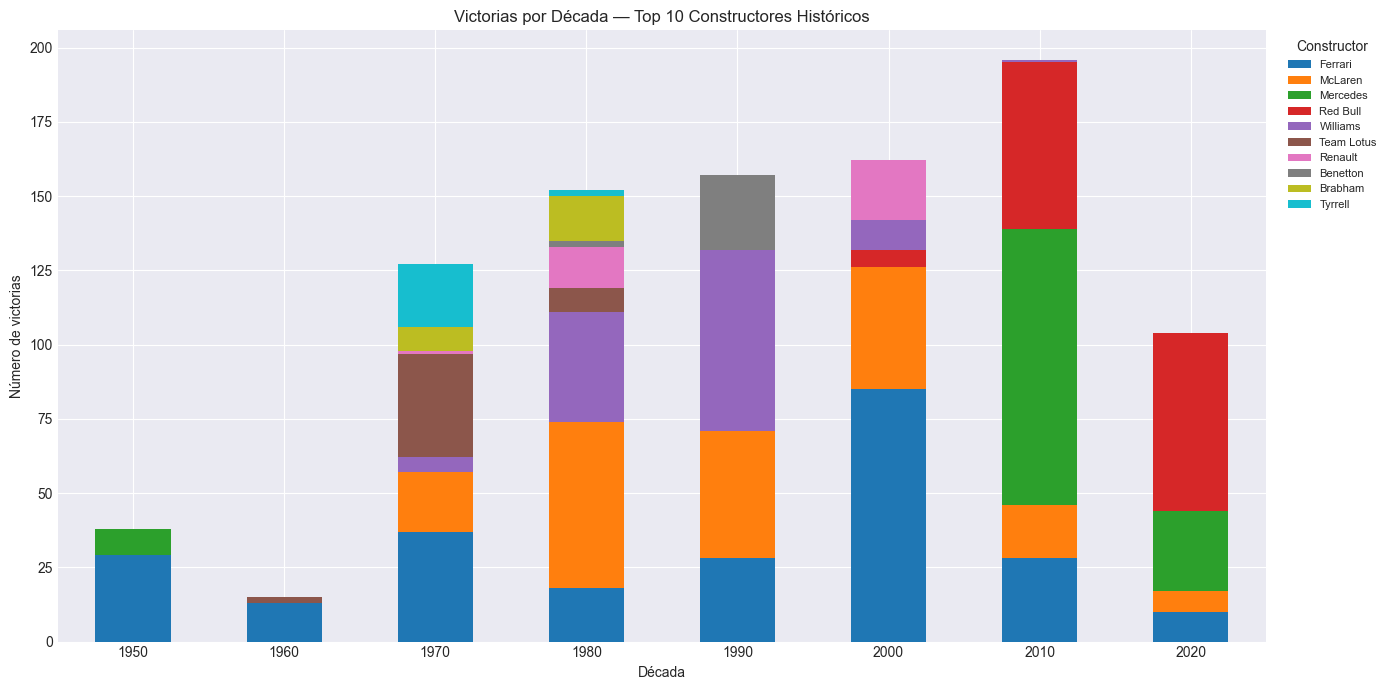

In [25]:
#4.3 DOMINANCIA POR DÉCADAS

dom_decada = (
    df[df['positionOrder'] == 1]
    .groupby(['decada', 'constructor_name'])
    .size()
    .reset_index(name='victorias')
)

# Equipo líder por década
lider_decada = (
    dom_decada.sort_values(['decada','victorias'], ascending=[True, False])
    .groupby('decada').first().reset_index()
    .rename(columns={'constructor_name':'lider','victorias':'v_lider'})
)

# Total de carreras por década
total_decada = df[df['positionOrder']==1].groupby('decada').size().reset_index(name='total_v')
lider_decada = lider_decada.merge(total_decada, on='decada')
lider_decada['pct_dominancia'] = (lider_decada['v_lider'] / lider_decada['total_v'] * 100).round(1)

print("Equipo dominante por década:")
display(lider_decada)

# Gráfico
pivot = dom_decada.pivot_table(index='decada', columns='constructor_name', 
                                values='victorias', fill_value=0)
top10_eq = df[df['positionOrder']==1].groupby('constructor_name').size().nlargest(10).index
pivot_top = pivot[[c for c in top10_eq if c in pivot.columns]]

ax = pivot_top.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.xlabel("Década")
plt.ylabel("Número de victorias")
plt.title("Victorias por Década — Top 10 Constructores Históricos")
plt.xticks(rotation=0)
plt.legend(title='Constructor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

###  Respuesta a la Pregunta 3

>La dominancia en F1 cambia cada 10-15 años, se aplica por los grandes cambios reglamentarios motores, aerodinámica, neumáticos.

## 4.4 Pregunta 4: ¿Qué pilotos destacan por sus remontadas extremas?

Las remontadas extremas revelan pilotos con capacidad excepcional de gestión de carrera, estrategia y agresividad.

TOP 15 MEJORES REMONTADAS (mejor resultado individual por piloto):


,piloto,descripcion,pos_delta
0,VET Vettel,P24→P3 (2012),21
1,HAM Hamilton,P22→P3 (2014),19
2,MSC Schumacher,P24→P5 (2011),19
3,RAI Räikkönen,P22→P3 (2006),19
4,TRU Trulli,P22→P4 (2006),18
5,MON Pablo Montoya,P20→P2 (2005),18
6,VER Verstappen,P20→P2 (2021),18
7,ALO Alonso,P24→P6 (2010),18
8,KOV Kovalainen,P22→P4 (2007),18
9,SAI Sainz,P20→P3 (2019),17


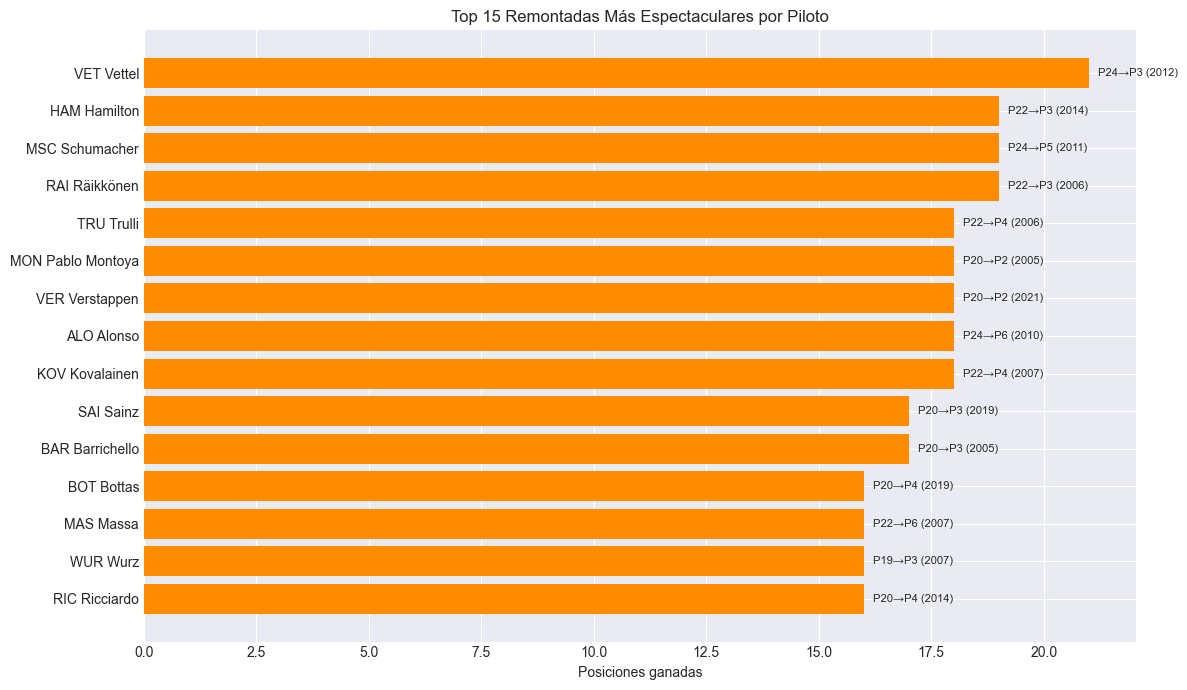

In [26]:
#4.4 MEJORES REMONTADORES

mejores_remontadores = (
    df[(df['dnf'] == 0) & (df['grid'] > 1)]
    .sort_values('pos_delta', ascending=False)
    .groupby(['driverId', 'code', 'surname'])
    .head(1)[['driverId', 'code', 'surname', 'year', 'grid', 'positionOrder', 'pos_delta']]
    .sort_values('pos_delta', ascending=False)
    .head(15)
)

mejores_remontadores['piloto'] = mejores_remontadores['code'] + ' ' + mejores_remontadores['surname']
mejores_remontadores['descripcion'] = (
    'P' + mejores_remontadores['grid'].astype(int).astype(str) + 
    '→P' + mejores_remontadores['positionOrder'].astype(int).astype(str) +
    ' (' + mejores_remontadores['year'].astype(int).astype(str) + ')'
)

print("TOP 15 MEJORES REMONTADAS (mejor resultado individual por piloto):")
display(mejores_remontadores[['piloto', 'descripcion', 'pos_delta']].reset_index(drop=True))

plt.figure(figsize=(12, 7))
bars = plt.barh(mejores_remontadores['piloto'], mejores_remontadores['pos_delta'], color='darkorange')
for bar, row in zip(bars, mejores_remontadores.itertuples()):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             row.descripcion, va='center', fontsize=8)
plt.xlabel("Posiciones ganadas")
plt.title("Top 15 Remontadas Más Espectaculares por Piloto")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###  Respuesta a la Pregunta 4

> Las remontadas extremas identifican pilotos con capacidad excepcional en condiciones adversas estas situaciones por salir desde el pitlane, penalizaciones en parrilla, accidentes al inicio y coches de seguridad.

## 4.5 Panel de Visualizaciones Integrado

Panel resumen con los 9 indicadores más relevantes del análisis.

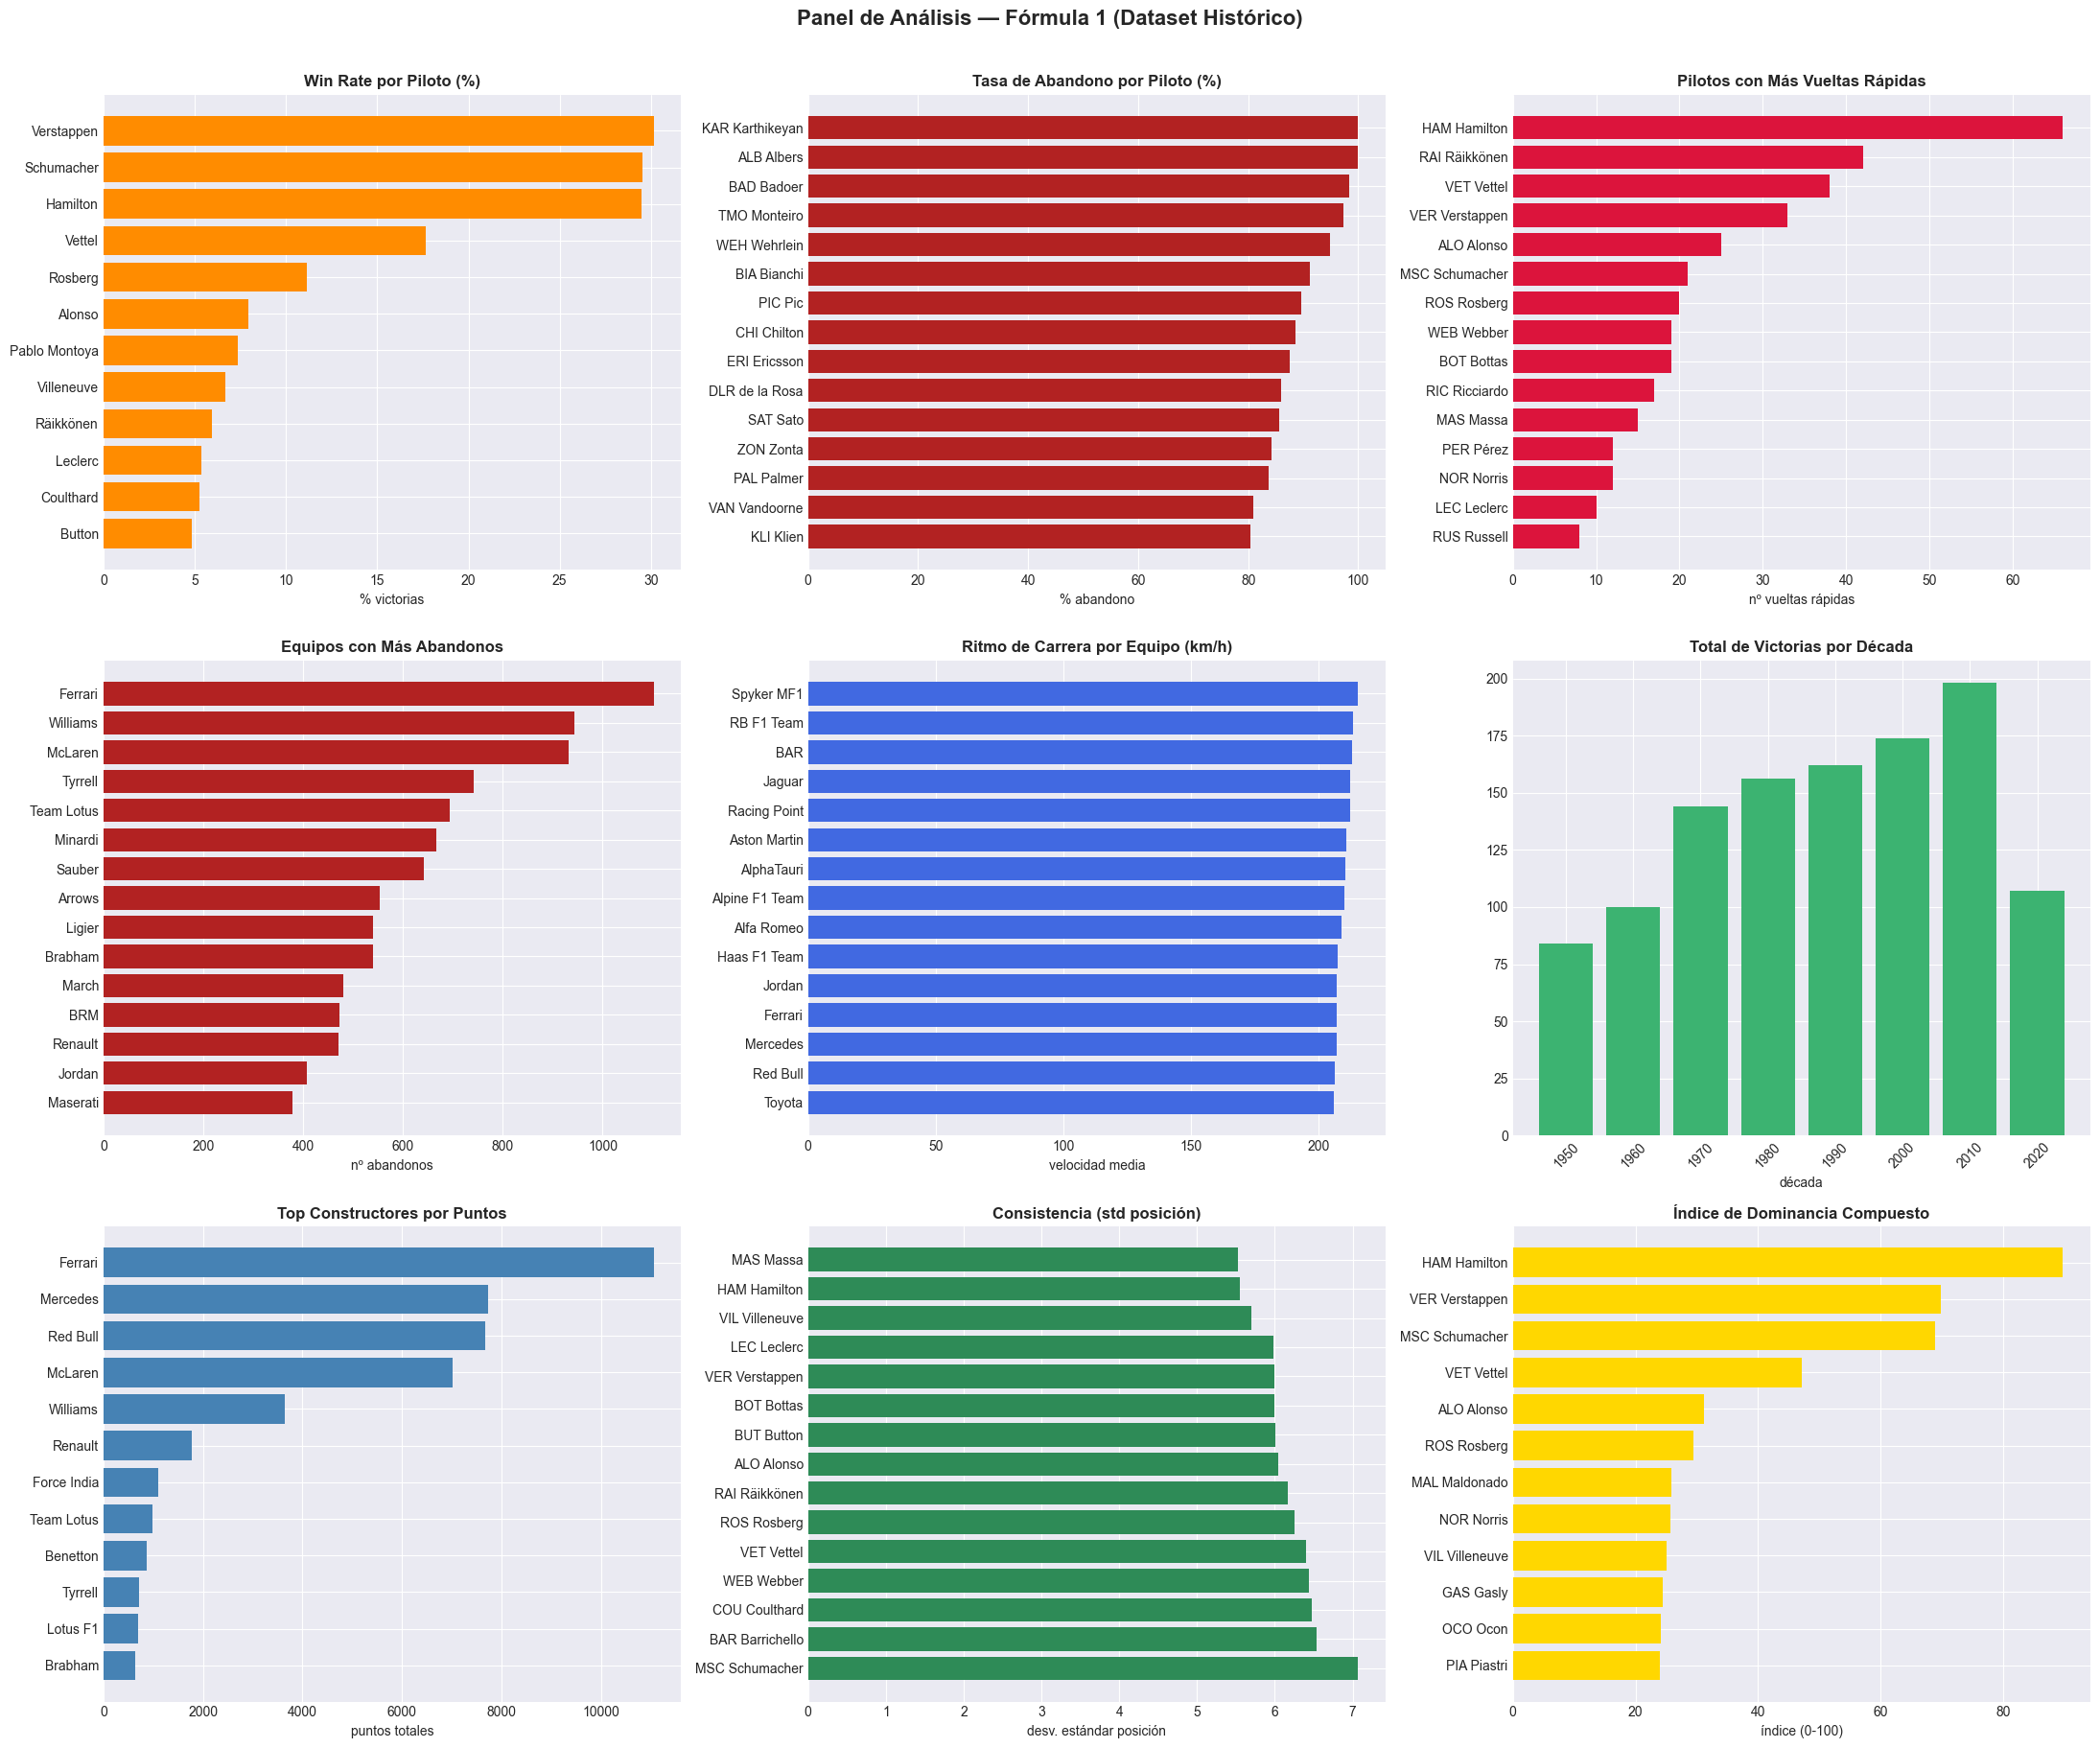

Panel guardado


In [27]:
# 4.5 PANEL RESUMEN
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Panel de Análisis — Fórmula 1 (Dataset Histórico)', fontsize=16, fontweight='bold', y=1.01)

# 1 Win Rate
ax = axes[0, 0]
tw = win_rate.sort_values('win_rate', ascending=False).head(12)
ax.barh(tw['surname'], tw['win_rate'], color='darkorange')
ax.invert_yaxis()
ax.set_title("Win Rate por Piloto (%)", fontweight='bold')
ax.set_xlabel("% victorias")

# 2 Abandono pilotos
ax = axes[0, 1]
ax.barh(top_aband['piloto'], top_aband['porcentaje_abandono'], color='firebrick')
ax.invert_yaxis()
ax.set_title("Tasa de Abandono por Piloto (%)", fontweight='bold')
ax.set_xlabel("% abandono")

# 3 Vueltas rápidas
ax = axes[0, 2]
ax.barh(top_fastest['piloto'], top_fastest['fastest_laps'], color='crimson')
ax.invert_yaxis()
ax.set_title("Pilotos con Más Vueltas Rápidas", fontweight='bold')
ax.set_xlabel("nº vueltas rápidas")

# 4 Abandono equipos
ax = axes[1, 0]
ax.barh(aband_equipos['constructor_name'], aband_equipos['abandonos'], color='firebrick')
ax.invert_yaxis()
ax.set_title("Equipos con Más Abandonos", fontweight='bold')
ax.set_xlabel("nº abandonos")

# 5 Ritmo equipos
ax = axes[1, 1]
ax.barh(top_ritmo['constructor_name'], top_ritmo['fastestLapSpeed'], color='royalblue')
ax.invert_yaxis()
ax.set_title("Ritmo de Carrera por Equipo (km/h)", fontweight='bold')
ax.set_xlabel("velocidad media")

# 6 Dominancia por década
ax = axes[1, 2]
dom_simple = (df[df['positionOrder']==1]
              .groupby('decada').size().reset_index(name='victorias'))
ax.bar(dom_simple['decada'].astype(str), dom_simple['victorias'], color='mediumseagreen')
ax.set_title("Total de Victorias por Década", fontweight='bold')
ax.set_xlabel("década")
ax.set_xticklabels(dom_simple['decada'].astype(str), rotation=45)

# 7 Top constructores
ax = axes[2, 0]
tc = top_constructors.head(12)
ax.barh(tc['constructor_name'], tc['total_points'], color='steelblue')
ax.invert_yaxis()
ax.set_title("Top Constructores por Puntos", fontweight='bold')
ax.set_xlabel("puntos totales")

# 8 Consistencia pilotos
ax = axes[2, 1]
ax.barh(consistencia['piloto'], consistencia['std_pos'], color='seagreen')
ax.invert_yaxis()
ax.set_title("Consistencia (std posición)", fontweight='bold')
ax.set_xlabel("desv. estándar posición")

# 9 Índice de dominancia
ax = axes[2, 2]
top_dom = dominancia_pilotos.head(12)
top_dom['piloto'] = top_dom['code'] + ' ' + top_dom['surname']
ax.barh(top_dom['piloto'], top_dom['indice_dominancia'], color='gold')
ax.invert_yaxis()
ax.set_title("Índice de Dominancia Compuesto", fontweight='bold')
ax.set_xlabel("índice (0-100)")

plt.tight_layout()
output_path = os.path.join("Visualizaciones", "panel_f1.png")
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Panel guardado")

---

#  FASE 5: Documentación, Conclusiones y Recomendaciones

Esta fase sintetiza todos los hallazgos del análisis en **conclusiones accionables** y formula **recomendaciones** basadas en datos para equipos, analistas y estrategas de Fórmula 1.

## 5.1 Resumen de Insights Principales

Hallazgos más relevantes

###  1: El Win Rate corrige la injusticia del conteo absoluto
Hallazgo: Pilotos con pocas temporadas pueden tener un win rate superior a leyendas con décadas de carrera.  
Implicación: Comparar pilotos por victorias absolutas penaliza a quienes tuvieron carreras más cortas o coches menos competitivos.  

###  2: La consistencia predice los campeonatos
Hallazgo: Los campeones del mundo tienen sistemáticamente una desviación estándar de posición más baja que el promedio.  
Implicación: No basta con ganar muchas carreras; hay que puntuar siempre, incluso en días malos.  

###   3: La dominancia cambia con el reglamento, no con el talento
Hallazgo: Cada cambio reglamentario mayor redistribuye el poder entre equipos.  
Implicación: Las comparaciones entre eras distintas son inherentemente injustas sin contextualización.  

###   4: La fiabilidad vale tanto como la velocidad
Hallazgo: Equipos con alto ritmo pero muchos DNF pierden campeonatos frente a rivales más fiables.  
Implicación: El "triángulo" velocidad-fiabilidad-consistencia es el marco correcto para evaluar equipos.  

###   5: La parrilla influye mucho, pero no lo determina todo
Hallazgo: Existe una correlación positiva fuerte entre la posición de parrilla y la posición final.  
Implicación: La estrategia de clasificación es crucial, pero las remontadas demuestran que no es el único factor.  

###   6: Las remontadas identifican pilotos excepcionales bajo presión
Hallazgo: Los pilotos con más remontadas extremas exhiben habilidades superiores en gestión de neumáticos, adelantamiento y lectura de carrera.  
Implicación: Este perfil es muy valioso en temporadas con circuitos urbanos y condiciones variables.

###   7: El ritmo de carrera correlaciona con las victorias, pero no linealmente
Hallazgo: Los equipos con mayor fastestLapSpeed promedio no siempre son los más ganadores.  
Implicación: La estrategia de boxes y la gestión de neumáticos pueden superar la desventaja de ritmo puro.

###   8: Los equipos más ganadores también son los más consistentes
Hallazgo: Los constructores líderes tienen tanto más victorias como menor std_pos que la media.  
Implicación: La dominancia se construye con estabilidad organizativa, no con picos de rendimiento.

## 5.2 Recomendaciones

Basadas en los insights anteriores, estas son las 5 recomendaciones principales:

### Recomendación 1 — Usar un sistema de ranking más justo para los pilotos
Qué hacer: En lugar de comparar pilotos solo por victorias, usar una combinación de victorias, porcentaje de victorias y consistencia.  
Por qué: Un piloto con 50 victorias en 200 carreras no es necesariamente mejor que uno con 30 victorias en 80 carreras.

### Recomendación 2 — Evaluar los equipos de forma más completa
Qué hacer: Al analizar un equipo, no fijarse solo en los puntos totales, hay que tener en cuenta también su velocidad, cuántas veces abandona y cómo de regular es.  
Por qué: Hay equipos que son muy rápidos pero poco fiables, y eso les cuesta campeonatos un equipo equilibrado gana más a largo plazo.  

### Recomendación 3 — No comparar pilotos de épocas distintas sin contexto
Qué hacer: Cuando se comparen pilotos o equipos de diferentes décadas, hacerlo siempre dentro de su propia época.  
Por qué: En los años 50 había 7 carreras por temporada, hoy hay 23 los números no son comparables directamente.  

### Recomendación 4 — Valorar la capacidad de remontar
Qué hacer: Tener en cuenta cuánto suele mejorar un piloto su posición de salida a lo largo de la carrera.  
Por qué: Un piloto que regularmente sale 10º y termina 5º aporta mucho valor, aunque no gane muchas carreras.  

### Recomendación 5 — Hacer el análisis más accesible
Qué hacer: Crear una herramienta visual e interactiva donde cualquier persona pueda explorar los datos por piloto, equipo o año sin necesidad de saber programar.  
Por qué: Este análisis tiene mucho valor pero ahora mismo solo lo puede usar alguien técnico. Hacerlo accesible multiplica su utilidad.  

---

## 5.3 Conclusión General

Este proyecto ha demostrado que el análisis de datos de la fórmula 1 no es solo ganar. La integración de  métricas como la consistencia, fiabilidad, ritmo revela patrones que el ojo humano difícilmente captaría de otra forma.

Los resultados confirman que:

1. Los grandes campeones son consistentes, no solo rápidos, que la regularidad en los puntos es el factor más determinante para ganar campeonatos largos.

2. La dominancia es cíclica y reglamentaria que ningún equipo domina eternamente, que cada cambio de normativa es una oportunidad de redistribución del poder.

3. Los datos permiten comparaciones justas sin normalizar las participaciones y contextualización por era, las comparaciones históricas son engañosas.

4. La fiabilidad es tan valiosa como la velocidad, un motor que no explota vale más que un segundo por vuelta que nunca llega a meta.